# Tutorial 5a - 2D NMR from .magres files


```
      _
    /|_|\   
   / / \ \  
  /_/   \_\  
  \ \   / /  
   \ \_/ /  
    \|_|/  

```
SOPRANO: a Python library for generation, manipulation and analysis of large batches of crystalline structures


*Developed within the CCP-NC project. Copyright STFC 2022*

## 2D NMR correlation spectra

A 2D NMR correlation spectrum shows which atomic sites in a structure are coupled — for example, which ¹H sites are close to which ¹³C sites. In Soprano the workflow is:

1. **`NMRData2D`** — extract peak positions and correlation strengths from an ASE `Atoms` object (or supply them manually).
2. **`NMRPlot2D`** — render the 2D plot via matplotlib (or plotly), controlled by a **`PlotSettings`** object.

In this tutorial you will learn how to:
- Generate a minimal 2D NMR plot from a `.magres` file
- Filter peaks by interatomic distance (`rcut`)
- Choose or supply custom correlation-strength metrics
- Create Double-Quantum / Single-Quantum (DQ/SQ) plots
- Average over functional groups (e.g. CH₃, NH₃)
- Combine 2D and 1D spectra in a single figure
- Export peak data and contour grids for use in external tools

**Prerequisites:** Tutorial 05 (*1D NMR from .magres files*) covers `NMRCalculator` and `NMRFlags`, which are used in the "Combining 2D and 1D spectra" section below.

**Abbreviations used:** DQ = Double-Quantum, SQ = Single-Quantum, RSS = Root-Sum-Square, FWHM = Full Width at Half Maximum.

### Minimal 2D NMR plot

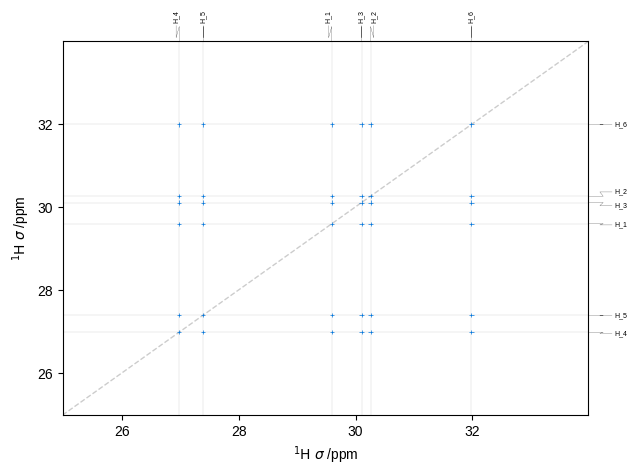

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import ase.io as ase_io

from soprano.calculate.nmr import NMRData2D, NMRPlot2D, PlotSettings, NMRCalculator, NMRFlags

ethanol = ase_io.read('tutorial_data/ethanol.magres')
edizum = ase_io.read('tutorial_data/EDIZUM.magres')

# Minimal plot: 1H-1H correlation from auto-generated peaks.
nmr_data = NMRData2D(ethanol, xelement='H')
NMRPlot2D(nmr_data).plot();

### Filtering the peaks by distance

A common task is to filter the peaks by distance. This can be done by using the `rcut` argument in the `NMRData2D` object. This argument is a float that represents the maximum distance in Å to consider for the automatic peak finder.

For this example let's use an atoms object with a lot more atoms, to see how the peak finder works with a more complex system.

We will plot all the C-H pairs in blue (circles) and those C-H pairs within 1.5 Å in red (crosses).

The total number of C-H pairs is 285
The C-H pairs within rcut=1.5 Å is 19


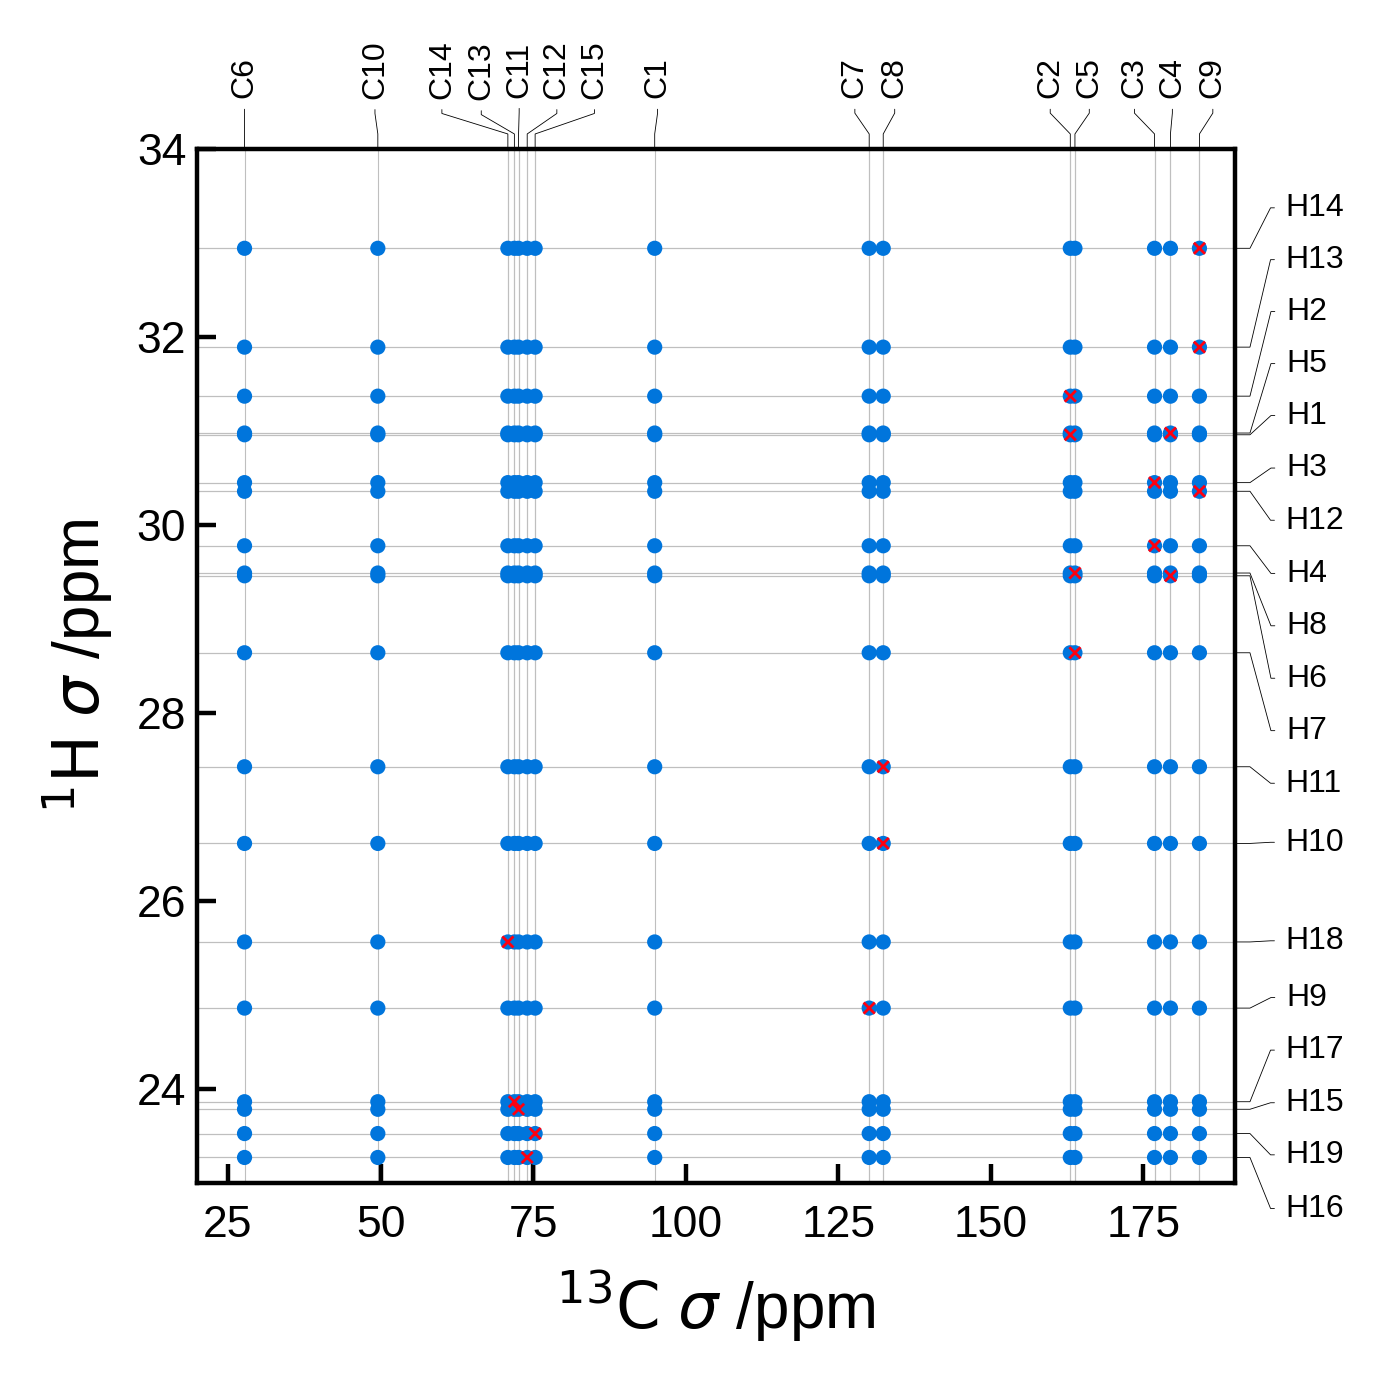

In [2]:
xlims = (20, 190) # ppm
ylims = (23, 34)  # ppm

# without any cut off radius:
nmr_data_all = NMRData2D(
    edizum,
    xelement = 'C',
    yelement = 'H',
    )
# There are 19 unique H and 15 unique C atoms in this unit cell.
# With 4 molecules per unit cell, that gives 4*19 * 4*15 = 4560 initial pairs,
# but peaks at the same (x, y, coupling) are merged automatically by
# `get_peaks(merge_identical=True)` (the default), leaving 285 distinct peaks.
# This is separate from `reduce=True`, which pre-filters the *atoms* by symmetry.

print(f"The total number of C-H pairs is {len(nmr_data_all.peaks)}")
plot_settings = PlotSettings(
    marker_color='C0',
    marker = 'o',
    max_marker_size=5,
    xlim=xlims,
    ylim=ylims,
    )

plot = NMRPlot2D(nmr_data_all, plot_settings)
fig, ax = plot.plot()

# with a cut off radius:
rcut = 1.5 # Angstrom
nmr_data_cut = NMRData2D(
    edizum,
    xelement = 'C',
    yelement = 'H',
    rcut = rcut # ** here is where we set the cut off radius **
    )

print(f"The C-H pairs within rcut={rcut} Å is {len(nmr_data_cut.peaks)}")

# Now we can plot the data
plot_settings = PlotSettings(
    marker_color='C5',
    marker = 'x',
    max_marker_size=4,
    show_labels=False, # no need to write them twice
    xlim=xlims,
    ylim=ylims,
    )
plot = NMRPlot2D(nmr_data_cut, plot_settings, ax=ax)
plot.plot();

### More advanced 2D NMR plot
For a more complete example, let's set a few more options explicitly. Below we plot a proton-proton DQ/SQ (Double-Quantum / Single-Quantum) plot. Note that since we set the references explicitly, the plot will be converted from magnetic shielding $\sigma$ to chemical shift $\delta$.

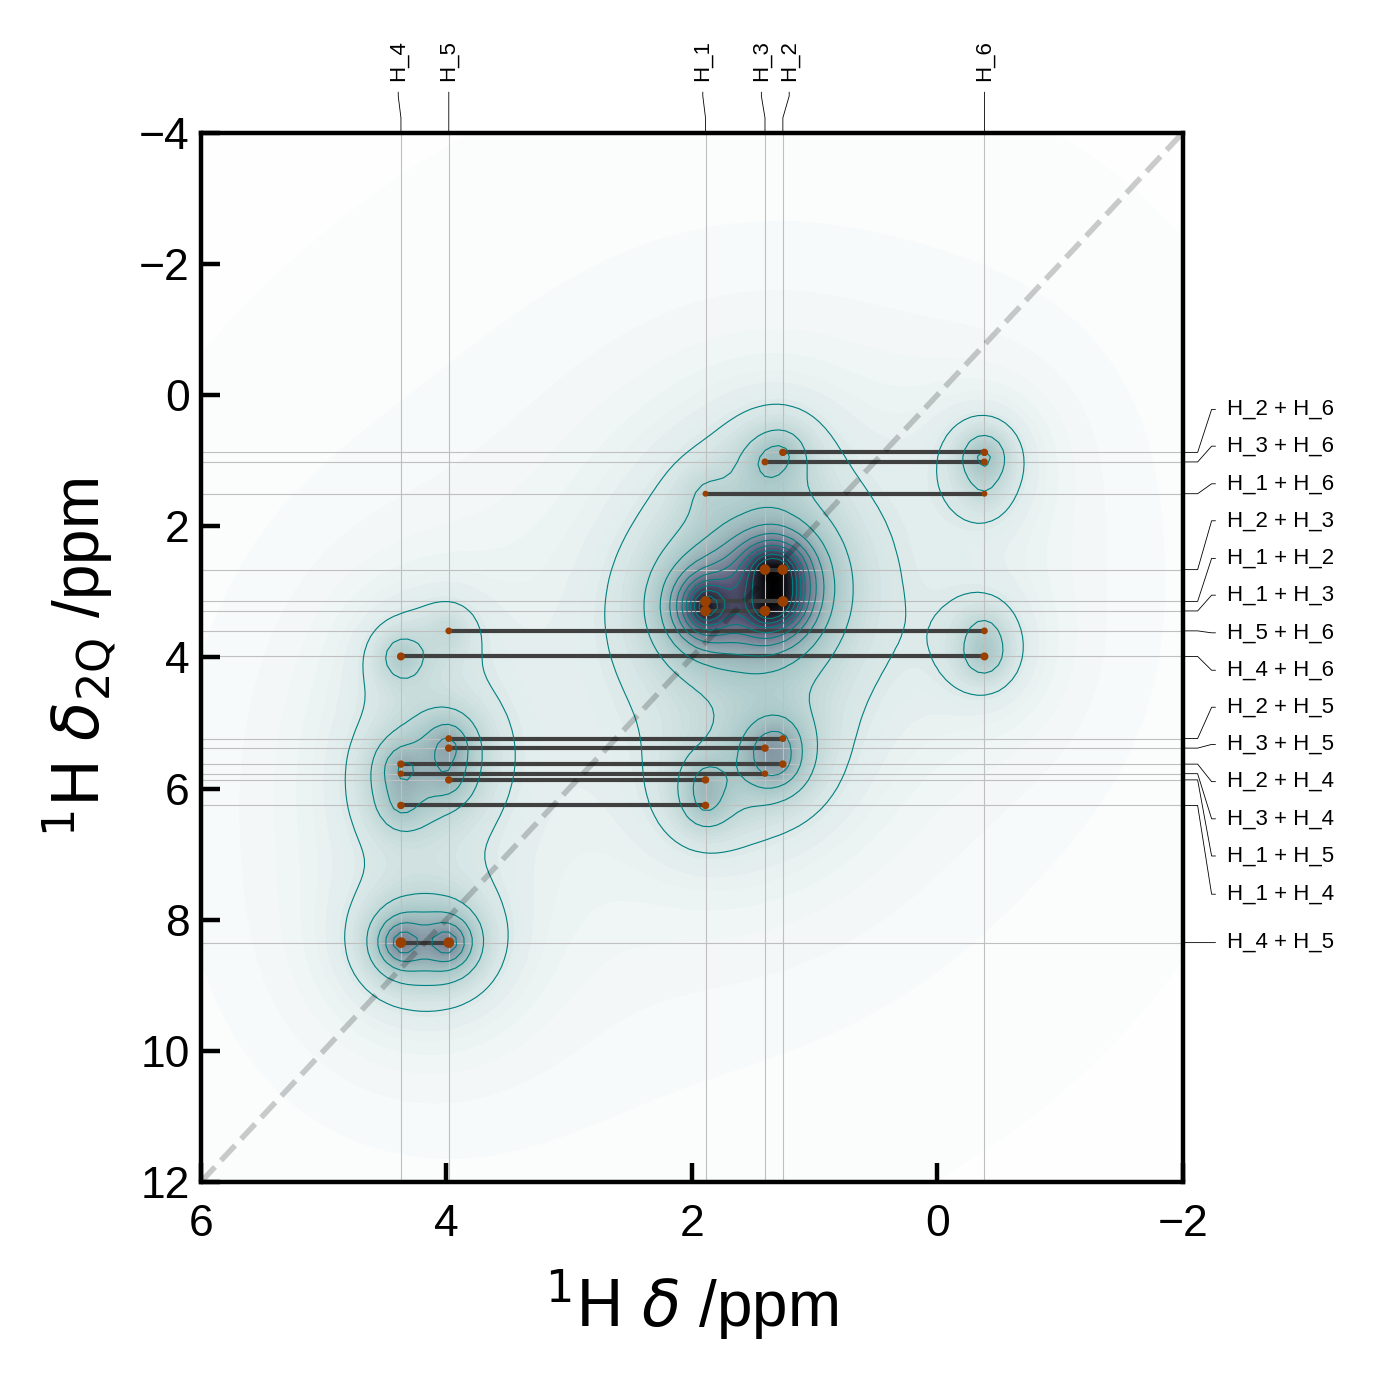

In [3]:
# Extract data for a 1H-1H DQ/SQ spectrum.
nmr_data = NMRData2D(
    ethanol,
    xelement='H',
    yelement='H',
    isotopes={'H': 1},
    references={'H': 30.0},
    gradients={'H': -0.95},
    yaxis_order='2Q',
    correlation_strength_metric='dipolar_rss',
)

plot_settings = PlotSettings(
    xlim=(6, -2),
    ylim=(12, -4),
    marker='o',
    marker_color='C1',
    max_marker_size=2,
    show_contour=True,
    contour_color='teal',
    contour_levels=10,
    contour_linewidth=0.2,
    show_heatmap=True,
    colormap='bone_r',
    heatmap_levels=100,
    heatmap_grid_size=800,
    show_connectors=True,
    label_fontsize=4,
    intensity_range=(10, 80),
    heatmap_range=(0, 100),
)

NMRPlot2D(nmr_data, plot_settings).plot();

###  Choosing which pairs to plot

You might want to supply the pairs of sites together with a measure of their correlation strength. This can be done by supplying the `pairs` argument with a list of tuples of the form `(i, j)` and the `correlation_strengths` argument. The `correlation_strengths` argument should be a list of the same length as `pairs` and contain the strength value for each pair. The sizes are normalised to the maximum size in the list.

The pair indices should always refer to the **full-cell** `Atoms` object. If you also set `reduce=True`, Soprano will automatically remap the indices to the reduced (asymmetric-unit) structure and emit a warning showing the old → new mapping.

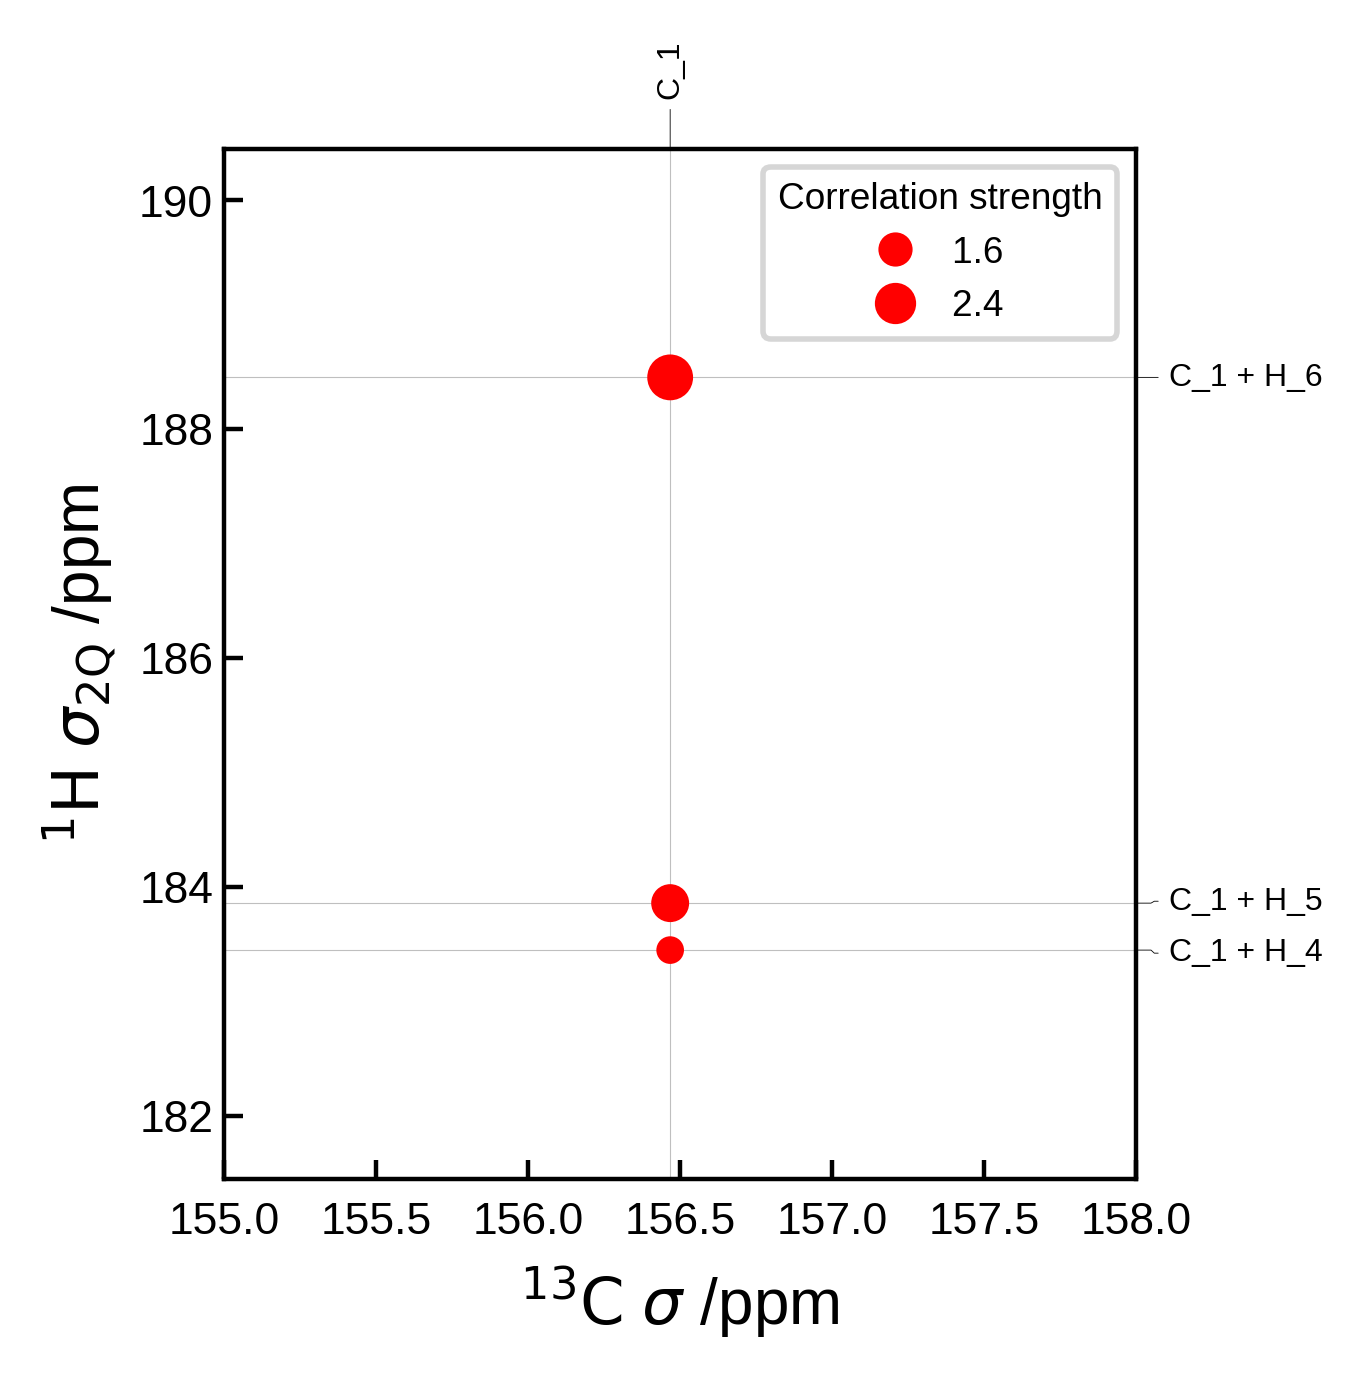

In [4]:
# Here's an artificial example of how you might select custom pairs to plot
pairs = [(6,3), (6,4), (6,5)]
# and assign them different markersizes/correlation strengths to indicate the relative correlation strength
# (these are normalised internally such that the max absolute value is set to the max marker size)
markersizes=  [1,2,3]

xelement = 'C'
yelement = 'H'
yaxis_order = '2Q'
xlim = (155, 158)

plot_settings = PlotSettings(
    xlim=xlim,
    marker='o',
    marker_color = 'red',
    max_marker_size=60,
    show_legend=True,
)

# Extract and plot the data
nmr_data = NMRData2D(
    ethanol,
    xelement = xelement,
    yelement = yelement,
    pairs=pairs,
    yaxis_order=yaxis_order,
    correlation_strengths=markersizes,
    )
plot = NMRPlot2D(nmr_data, plot_settings)
plot.plot();

### Custom peaks

Instead of supplying pairs, we can instead supply the peaks as a list of `Peak2D` objects. This allows us to set the peak location, strength etc. directly. The `pairs` and `markersizes` arguments are ignored in this case.

One advantage of doing this is that you no longer need an `Atoms` object to plot the spectrum. This can be useful if you have a list of peaks from a different source such as a CSV file.

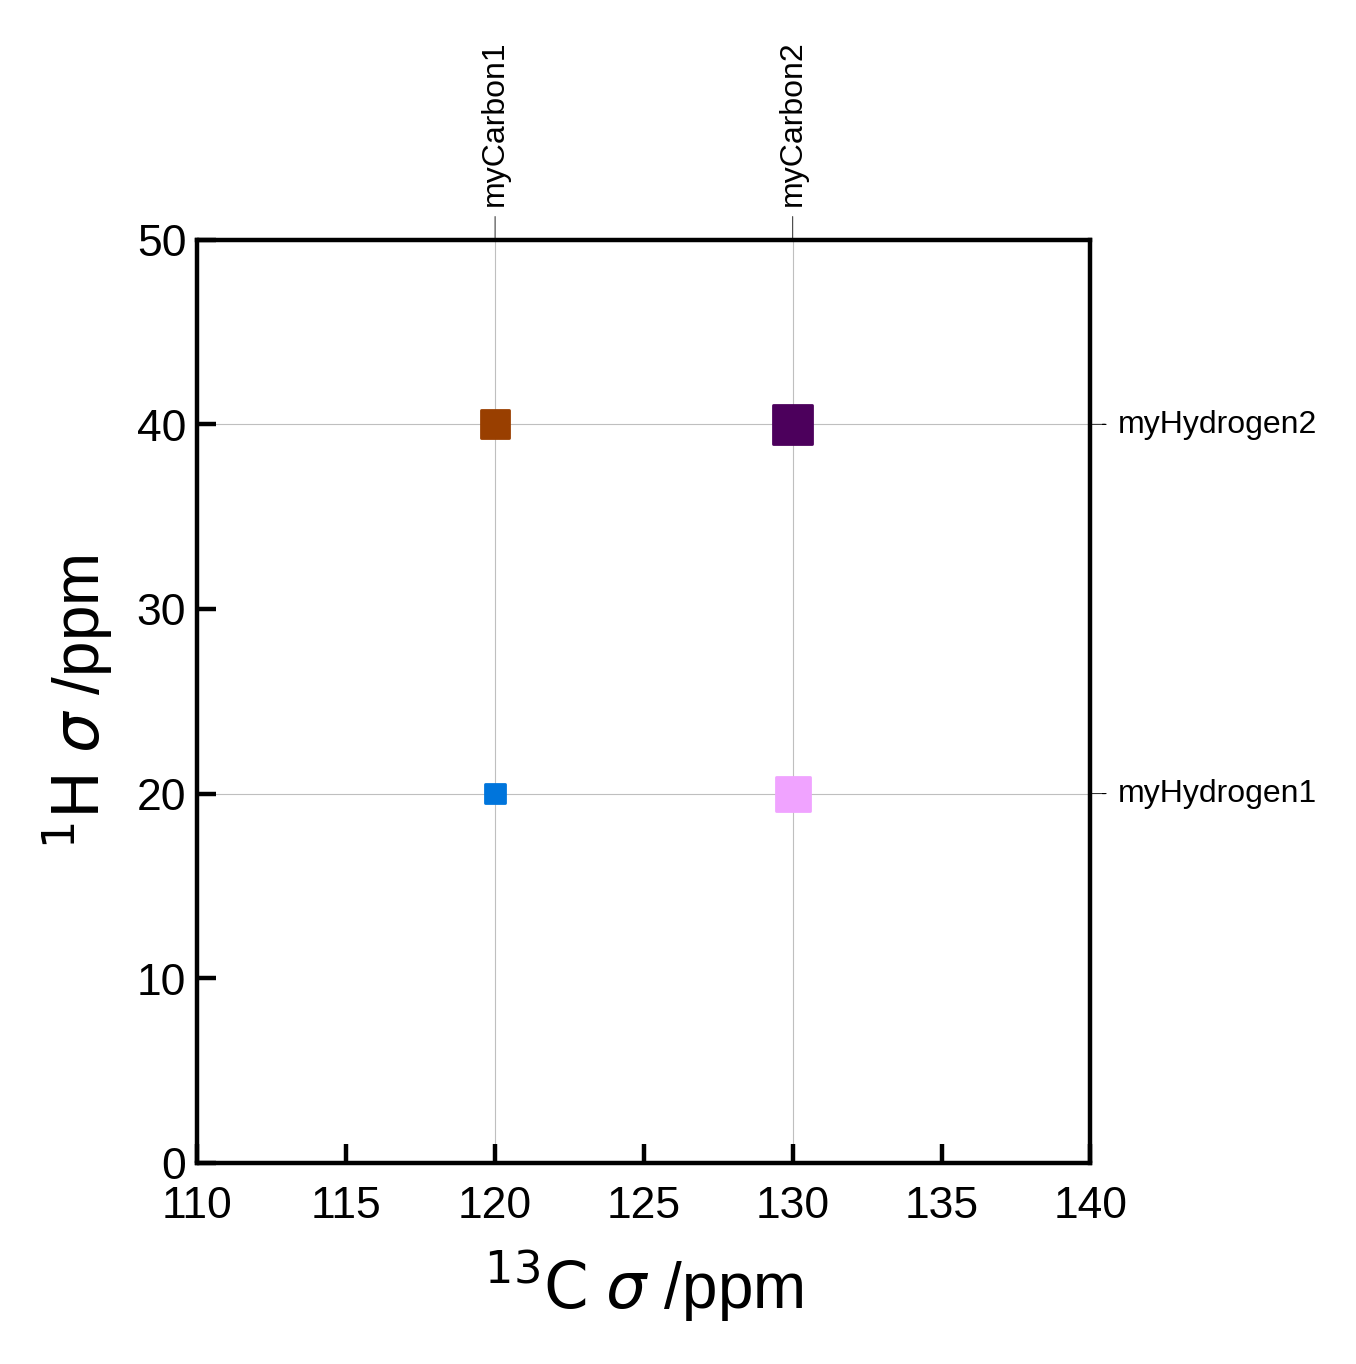

In [5]:
from soprano.calculate.nmr import Peak2D
# Artificial example of how you might define peaks if you have a list of carbon and hydrogen shieldings
C_ms = [120, 130]
H_ms = [20, 40]
correlation_strengths = [1, 2, 3, 4]
# Here we just create a peak for every combination of C and H chemical shifts, 
# and assign an arbitrary correlation strength based on the indices. 
# In practice you would replace this with your actual data.
peaks = []
for iC, C in enumerate(C_ms):
    for iH, H in enumerate(H_ms):
        peak = Peak2D(
                    C, # x position (ppm)
                    H, # y position (ppm)
                    f'myCarbon{iC+1}', # x label
                    f'myHydrogen{iH+1}', # y label
                    correlation_strength=correlation_strengths[iC * len(H_ms) + iH]
                    )
        peaks.append(peak)

# we can also get creative and assign different colors to the peaks:
peaks[0].color = 'C0'
peaks[1].color = 'C1'
peaks[2].color = 'C2'
peaks[3].color = 'C3'

nmr_data = NMRData2D(
    None, # we don't need the atoms object here if we provide the peaks
    peaks=peaks,
    x_axis_label=r"$\mathrm{^{13}C}$ $\sigma$ /ppm", # We can use LaTeX here
    y_axis_label=r"$\mathrm{^{1}H}$ $\sigma$ /ppm",  # We can use LaTeX here
)

plot_settings = PlotSettings(
    marker='s', # square marker
    xlim=(110, 140),
    ylim=(0, 50),
    max_marker_size=50,
)
plot = NMRPlot2D(nmr_data, plot_settings)
plot.plot();

### Editing peaks from automatic generation
If you don't want to create the Peak2D objects completely from scratch, we can get the automatically generated peaks, edit them and then plot them. 

For example, here we use Soprano to compute the J-coupling values for each peak and use that to determine the correlation strength.
Though note that we could also have simply used `correlation_strength_metric = jcoupling` in the `NMRData2D` object to achieve the same result, for this simple case.

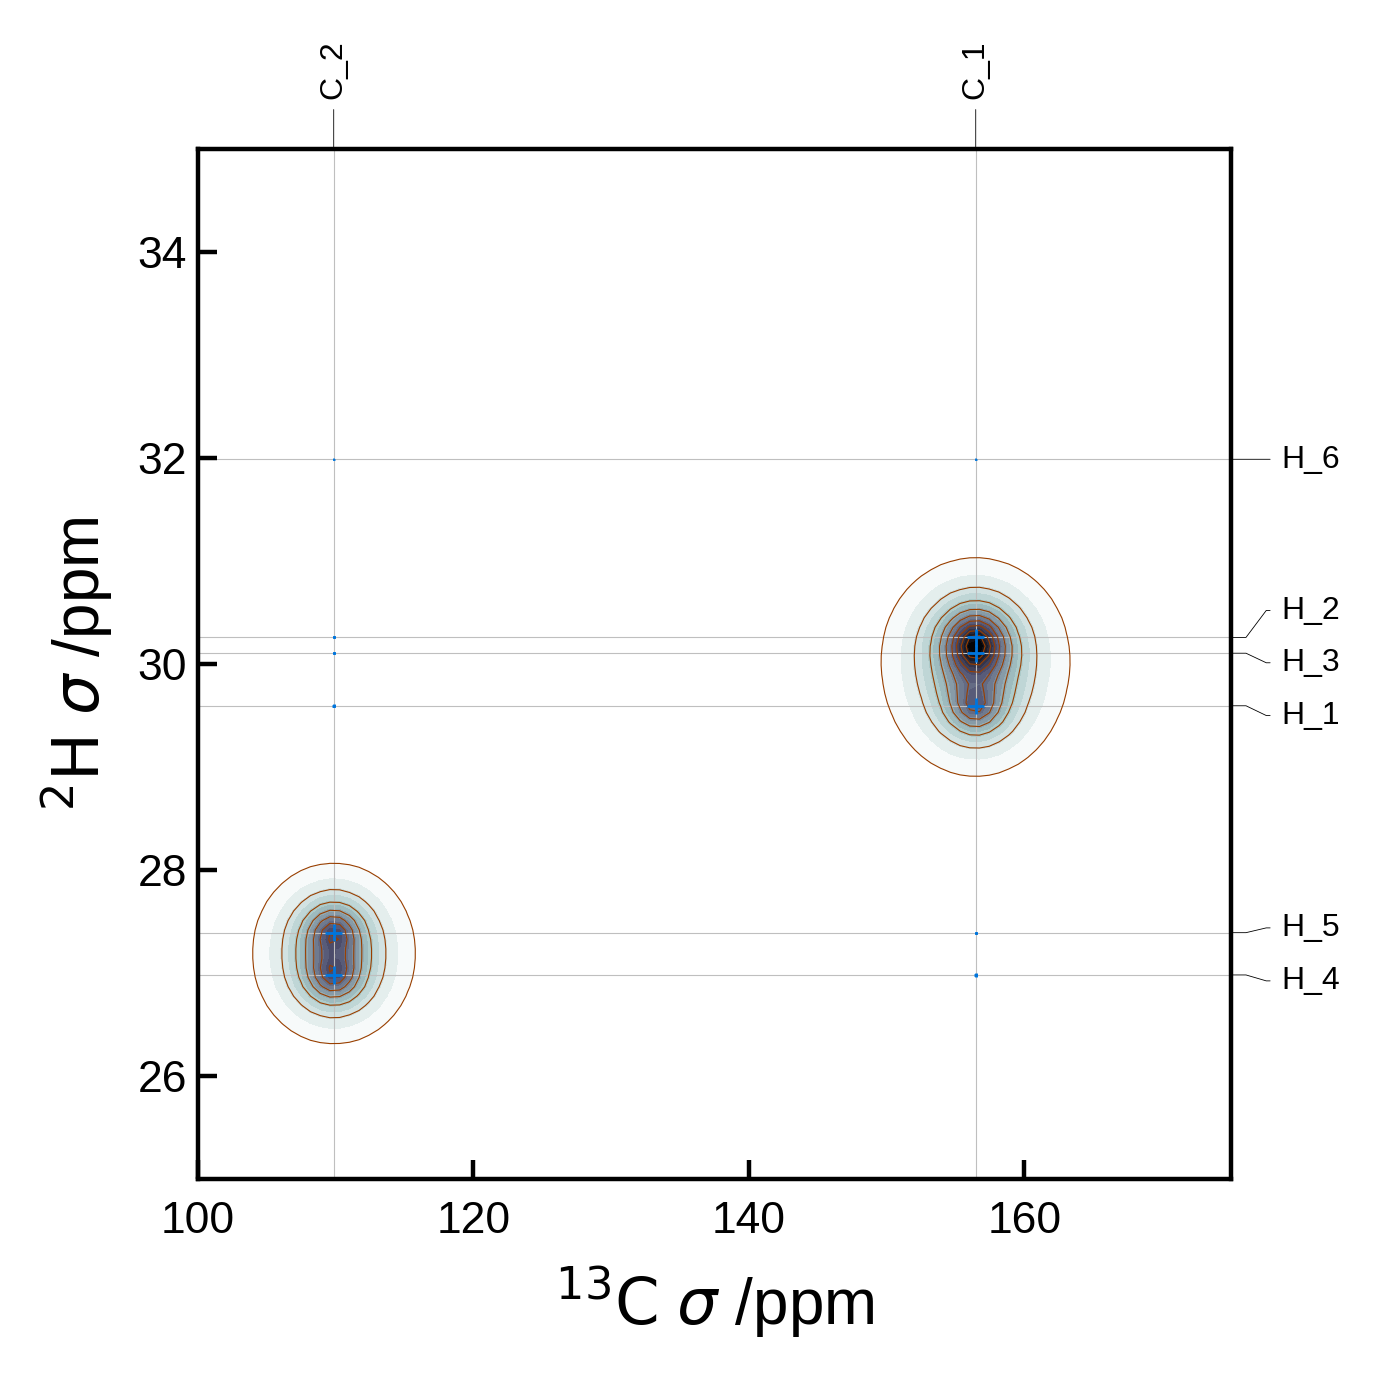

In [19]:
from soprano.properties.nmr.isc import JCIsotropy
# J-coupling depends on the nuclear gyromagnetic ratios.
# Here we use ²H to model isotope effects, mainly to highlight the
# fact that J-coupling values depend on the isotope's gyromagnetic ratio;
# (note: ¹H is the standard choice in most NMR experiments).
isotopes = {'C': 13, 'H': 2}
# Extract the data (including the peaks)
nmr_data = NMRData2D(ethanol, xelement = 'C', yelement = 'H', isotopes=isotopes)

# Now the peaks are available at `nmr_data.peaks`

# Loop over each peak and set the J-coupling for each peak to be the correlation strength
for peak in nmr_data.peaks:
    # Soprano wants the indices in ascending order
    i,j = sorted([peak.idx_x, peak.idx_y])
    # Get the J-coupling
    jcoup = JCIsotropy().get(ethanol,tag = 'isc', sel_i = [i], sel_j = [j], isotopes = isotopes)
    # Set the correlation strength to the J-coupling
    peak.correlation_strength = jcoup[(i,j)]

# Plot settings
plot_settings = PlotSettings(
    show_heatmap=True,
    show_contour=True,
    xlim=(100, 175),
    ylim=(25, 35),
    )

plot = NMRPlot2D(nmr_data, plot_settings)
fig, ax = plot.plot()

### Comparing in-built correlation strength metrics

We can compare the different correlation strength metrics by plotting them all on the same plot. Below we plot the same 2D NMR plot as above, but with the `correlation_strength_metric` argument set to `fixed`, `dipolar`, `jcoupling` and `inversedistance`.

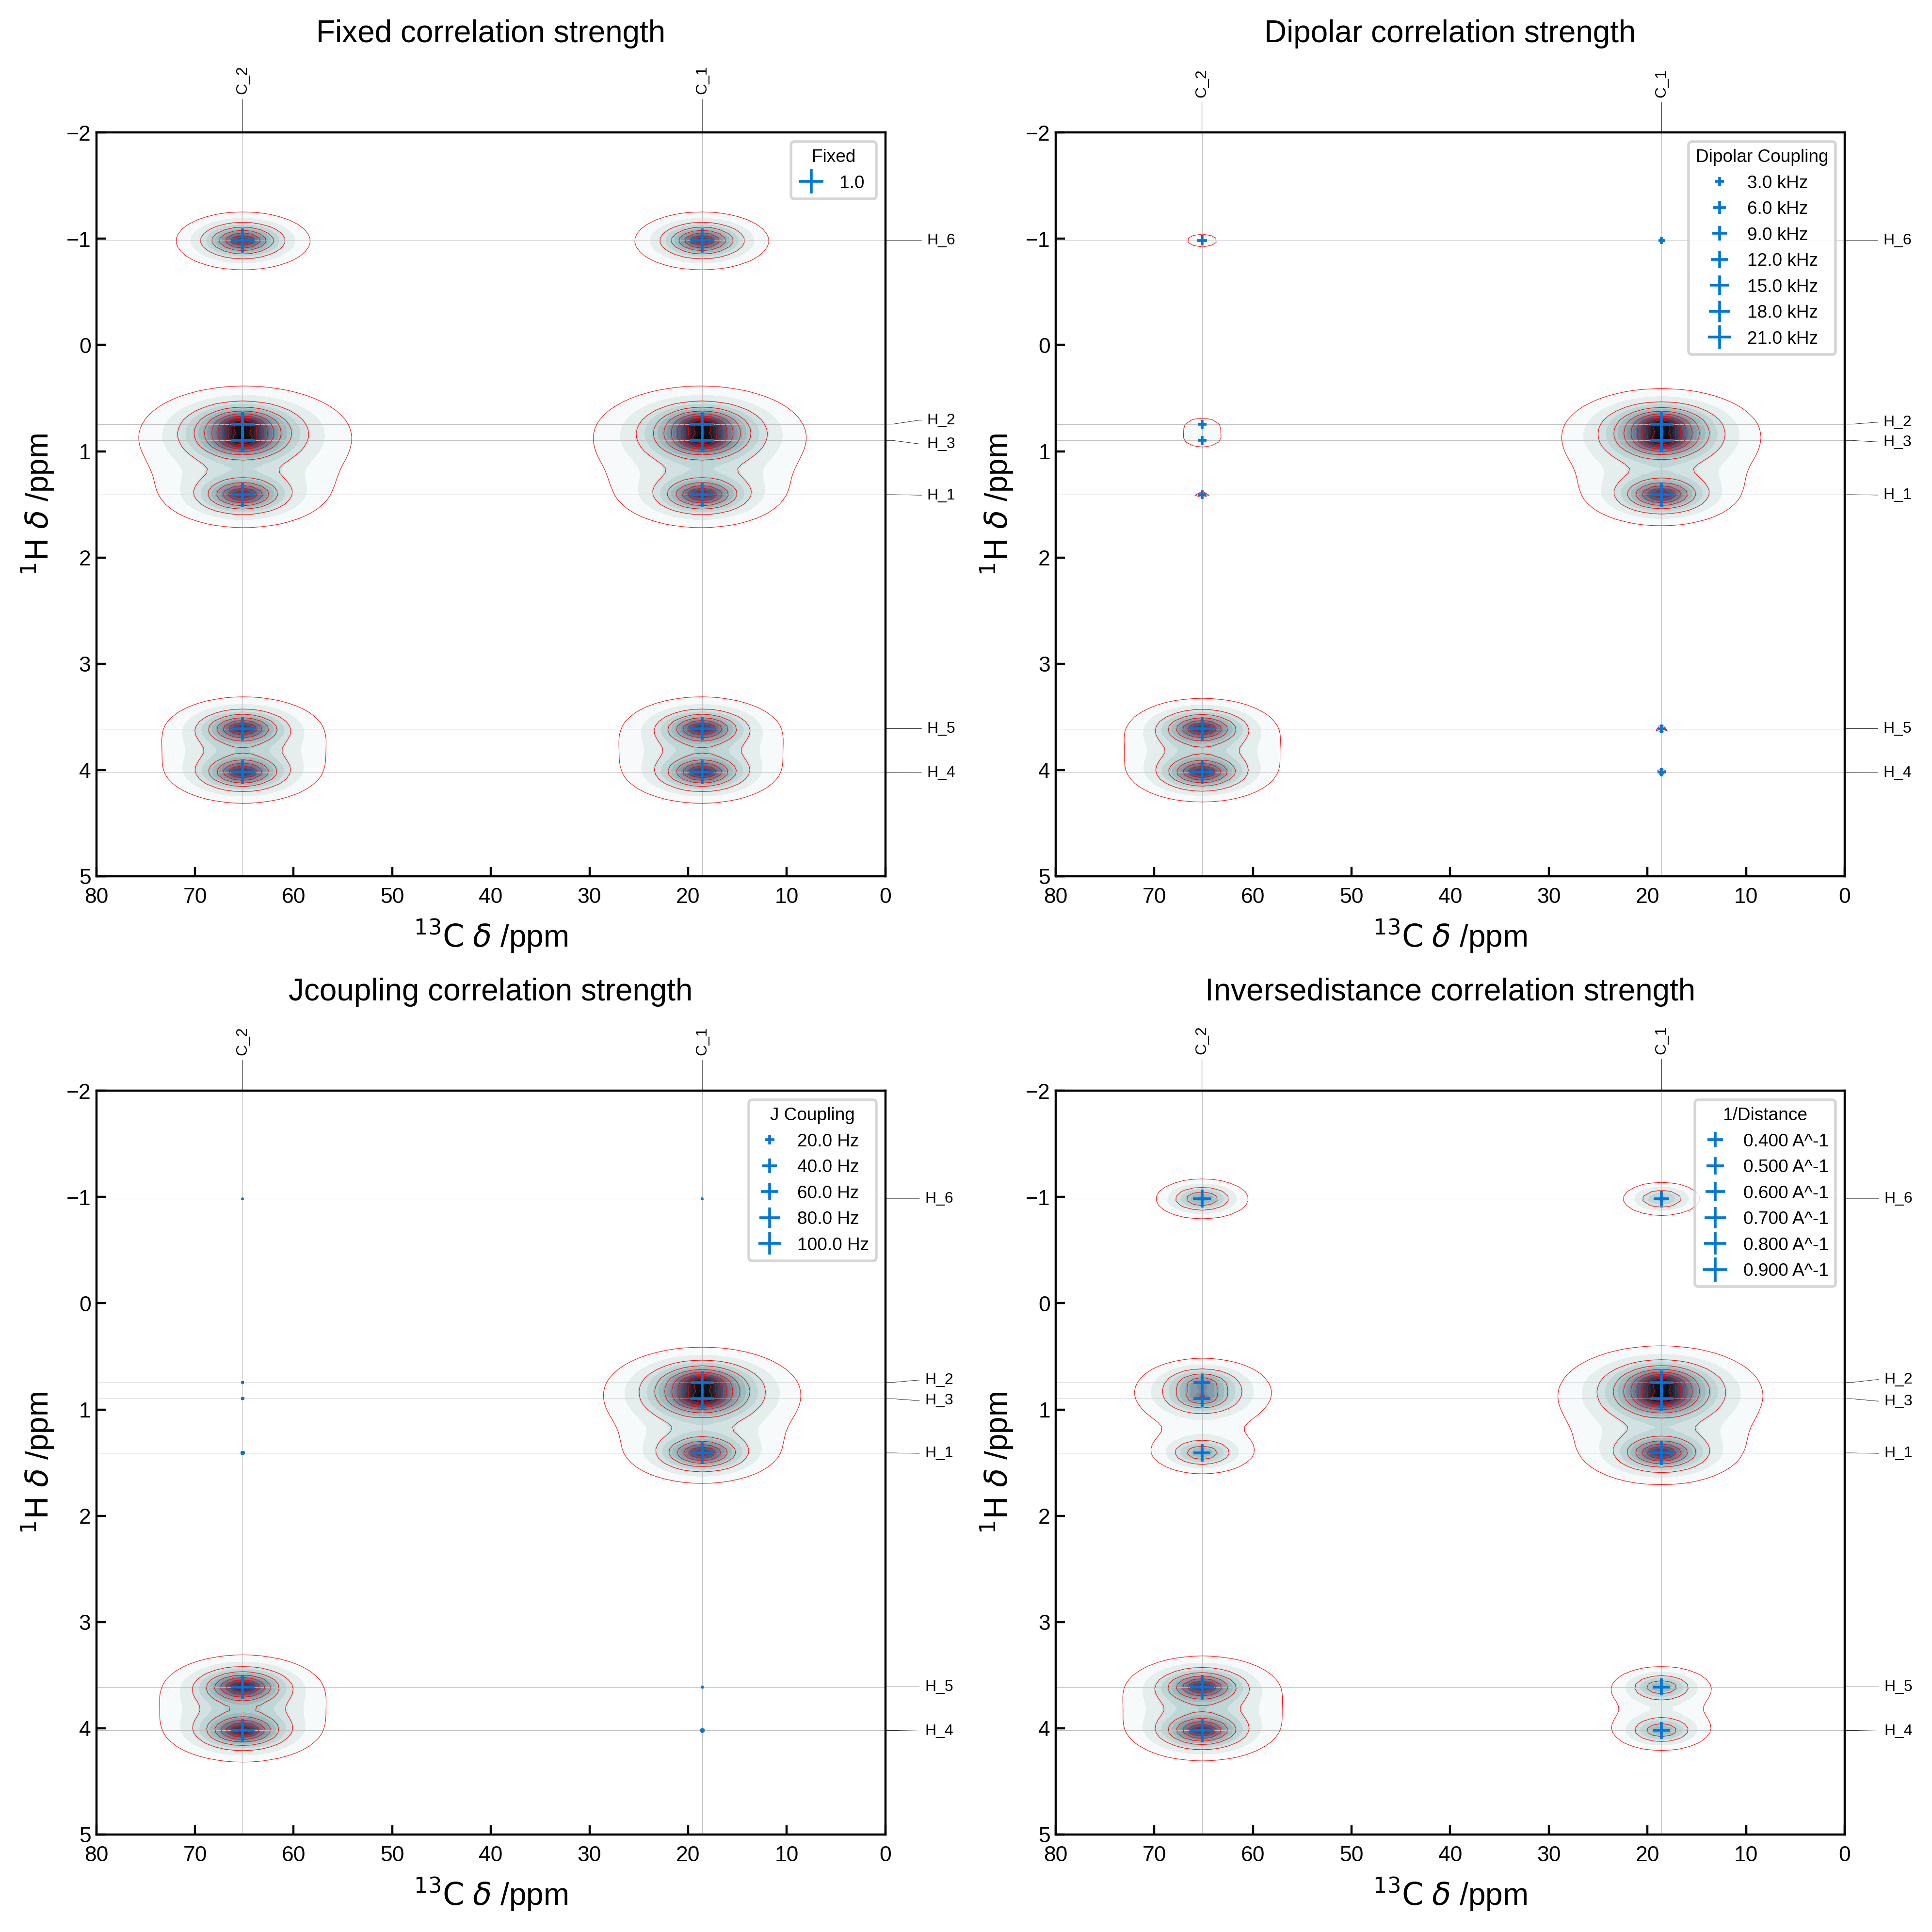

In [26]:
isotopes = {'C': 13, 'H': 1}

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
metrics = ['fixed', 'dipolar', 'jcoupling', 'inversedistance']
ylims = (5, -2)
xlims = (80, 0)

for i, metric in enumerate(metrics):
    nmr_data = NMRData2D(
        ethanol,
        xelement = 'C',
        yelement = 'H',
        isotopes=isotopes,
        correlation_strength_metric=metric,
        references={'C': 175, 'H': 31, 'O': 0},
        )
    plot_settings = PlotSettings(
        show_markers=True,
        max_marker_size=80,
        marker_linewidth=1,
        show_heatmap=True,
        show_contour=True,
        x_broadening=5,
        y_broadening=0.2,
        colormap='bone_r',
        contour_color='r',
        show_legend=True,
        heatmap_grid_size=600,
        )
    plot = NMRPlot2D(nmr_data, plot_settings, ax=axs[i])
    _ = plot.plot()
    axs[i].set_title(f'{metric.capitalize()} correlation strength', y=1.1)
    axs[i].set_ylim(ylims)
    axs[i].set_xlim(xlims)
    
plt.tight_layout()

### Functional group averaging (e.g. CH₃)

In many molecular solids the protons of a rapidly rotating methyl group (CH₃) are chemically equivalent.
We can pass `average_group='CH3'` to `NMRData2D` to merge those three H sites into a single representative peak.

Internally the merging happens **at the peaks level**, after all couplings have been computed from the real
atomic positions, so:

* **Peak position (x, y):** the mean of the group members' isotropic shifts — a genuine average shift.
* **Coupling:** the mean of the individual pair couplings (e.g. the average C–H₁, C–H₂, C–H₃ dipolar
  coupling), not a coupling evaluated at an artificial centroid.
* **Multiplicity** (`Peak2D.multiplicity`): the group size (3 for CH₃).

The multiplicity then weights both the **heatmap intensity** and **marker sizes**, so a CH₃ peak appears
three times stronger than a single-proton peak with the same coupling constant.

For DQ/SQ plots, the same averaging can be applied to the SQ dimension, so the three CH₃ protons would merge into a single SQ peak and you get a strong peak on the diagonal of the DQ/SQ plot at the position of the CH₃ protons.

Peaks after CH₃ averaging:
     C_1 – H_1,H_2,H_3  multiplicity=3  weight=69.24
     C_1 – H_4     multiplicity=1  weight=2.98
     C_1 – H_5     multiplicity=1  weight=2.99
     C_1 – H_6     multiplicity=1  weight=1.67
     C_2 – H_1,H_2,H_3  multiplicity=3  weight=8.96
     C_2 – H_4     multiplicity=1  weight=22.73
     C_2 – H_5     multiplicity=1  weight=23.18
     C_2 – H_6     multiplicity=1  weight=4.08


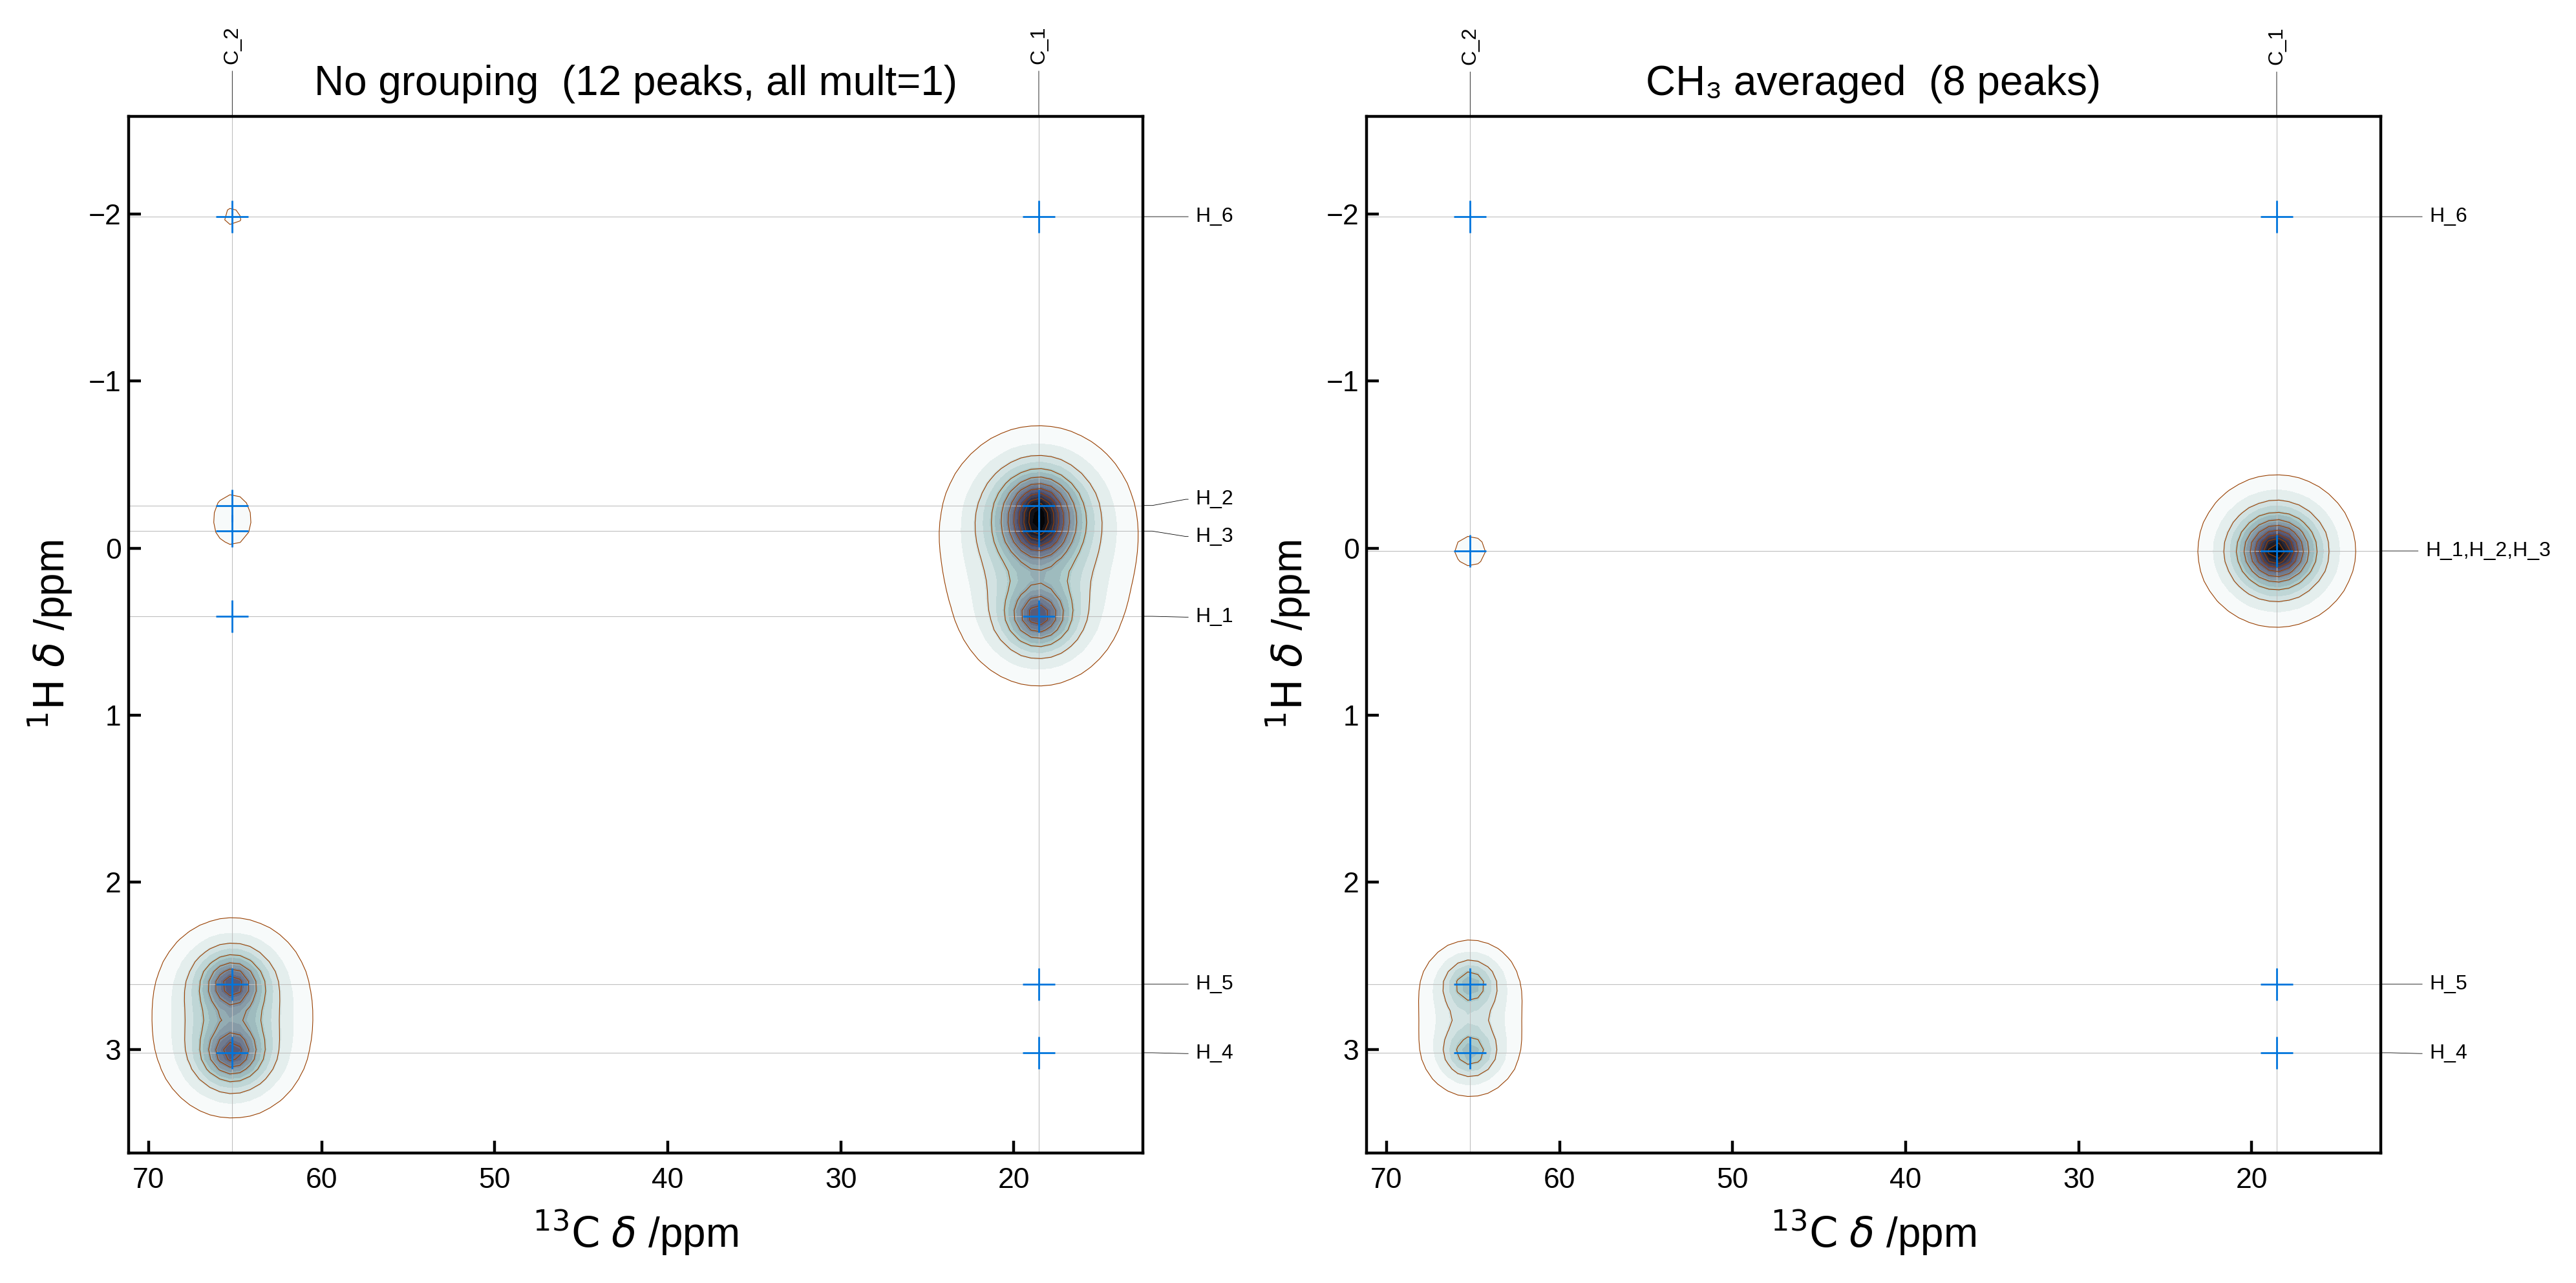

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_kw = dict(
    xelement='C',
    yelement='H',
    references={'C': 175, 'H': 30},
    correlation_strength_metric='dipolar',
)
settings_kw = dict(
    show_heatmap=True,
    show_contour=True,
    show_markers=True,
    x_broadening=3.0,
    y_broadening=0.3,
    colormap='bone_r',
    scale_markers=False,
    max_marker_size=80,
)

# --- No grouping: every H site is treated independently (multiplicity=1)
nmr_plain = NMRData2D(ethanol, **plot_kw)
plot_plain = NMRPlot2D(nmr_plain, PlotSettings(**settings_kw), ax=axes[0])
plot_plain.plot()
axes[0].set_title(f"No grouping  ({len(nmr_plain.peaks)} peaks, all mult=1)")

# --- CH₃ grouping: the three methyl H sites are merged into one peak
#     with multiplicity=3, making it appear 3× stronger in the heatmap
nmr_ch3 = NMRData2D(ethanol, average_group='CH3', **plot_kw)
plot_ch3 = NMRPlot2D(nmr_ch3, PlotSettings(**settings_kw), ax=axes[1])
plot_ch3.plot()
axes[1].set_title(f"CH₃ averaged  ({len(nmr_ch3.peaks)} peaks)")

# Print multiplicity and relative heatmap weight for each CH3-grouped peak
print("Peaks after CH₃ averaging:")
for p in nmr_ch3.peaks:
    weight = abs(p.correlation_strength) * p.multiplicity
    print(f"  {p.xlabel:>6} – {p.ylabel:<6}  multiplicity={p.multiplicity}  weight={weight:.2f}")

plt.tight_layout()

### Combining 2D and 1D spectra

More complex plots are possible by first manually generating the matplotlib figure and axes and passing the axis to the NMRPlot2D class' `plot` method. For example, we can create a customised plot in which we combine 2D and 1D spectra.

Note this is different from the "1D projections" of a 2D spectrum, which are generated by summing the intensities along one axis of the 2D spectrum. Here we are plotting a separate 1D spectrum alongside the 2D spectrum. We could get these from different sources or approximations. 


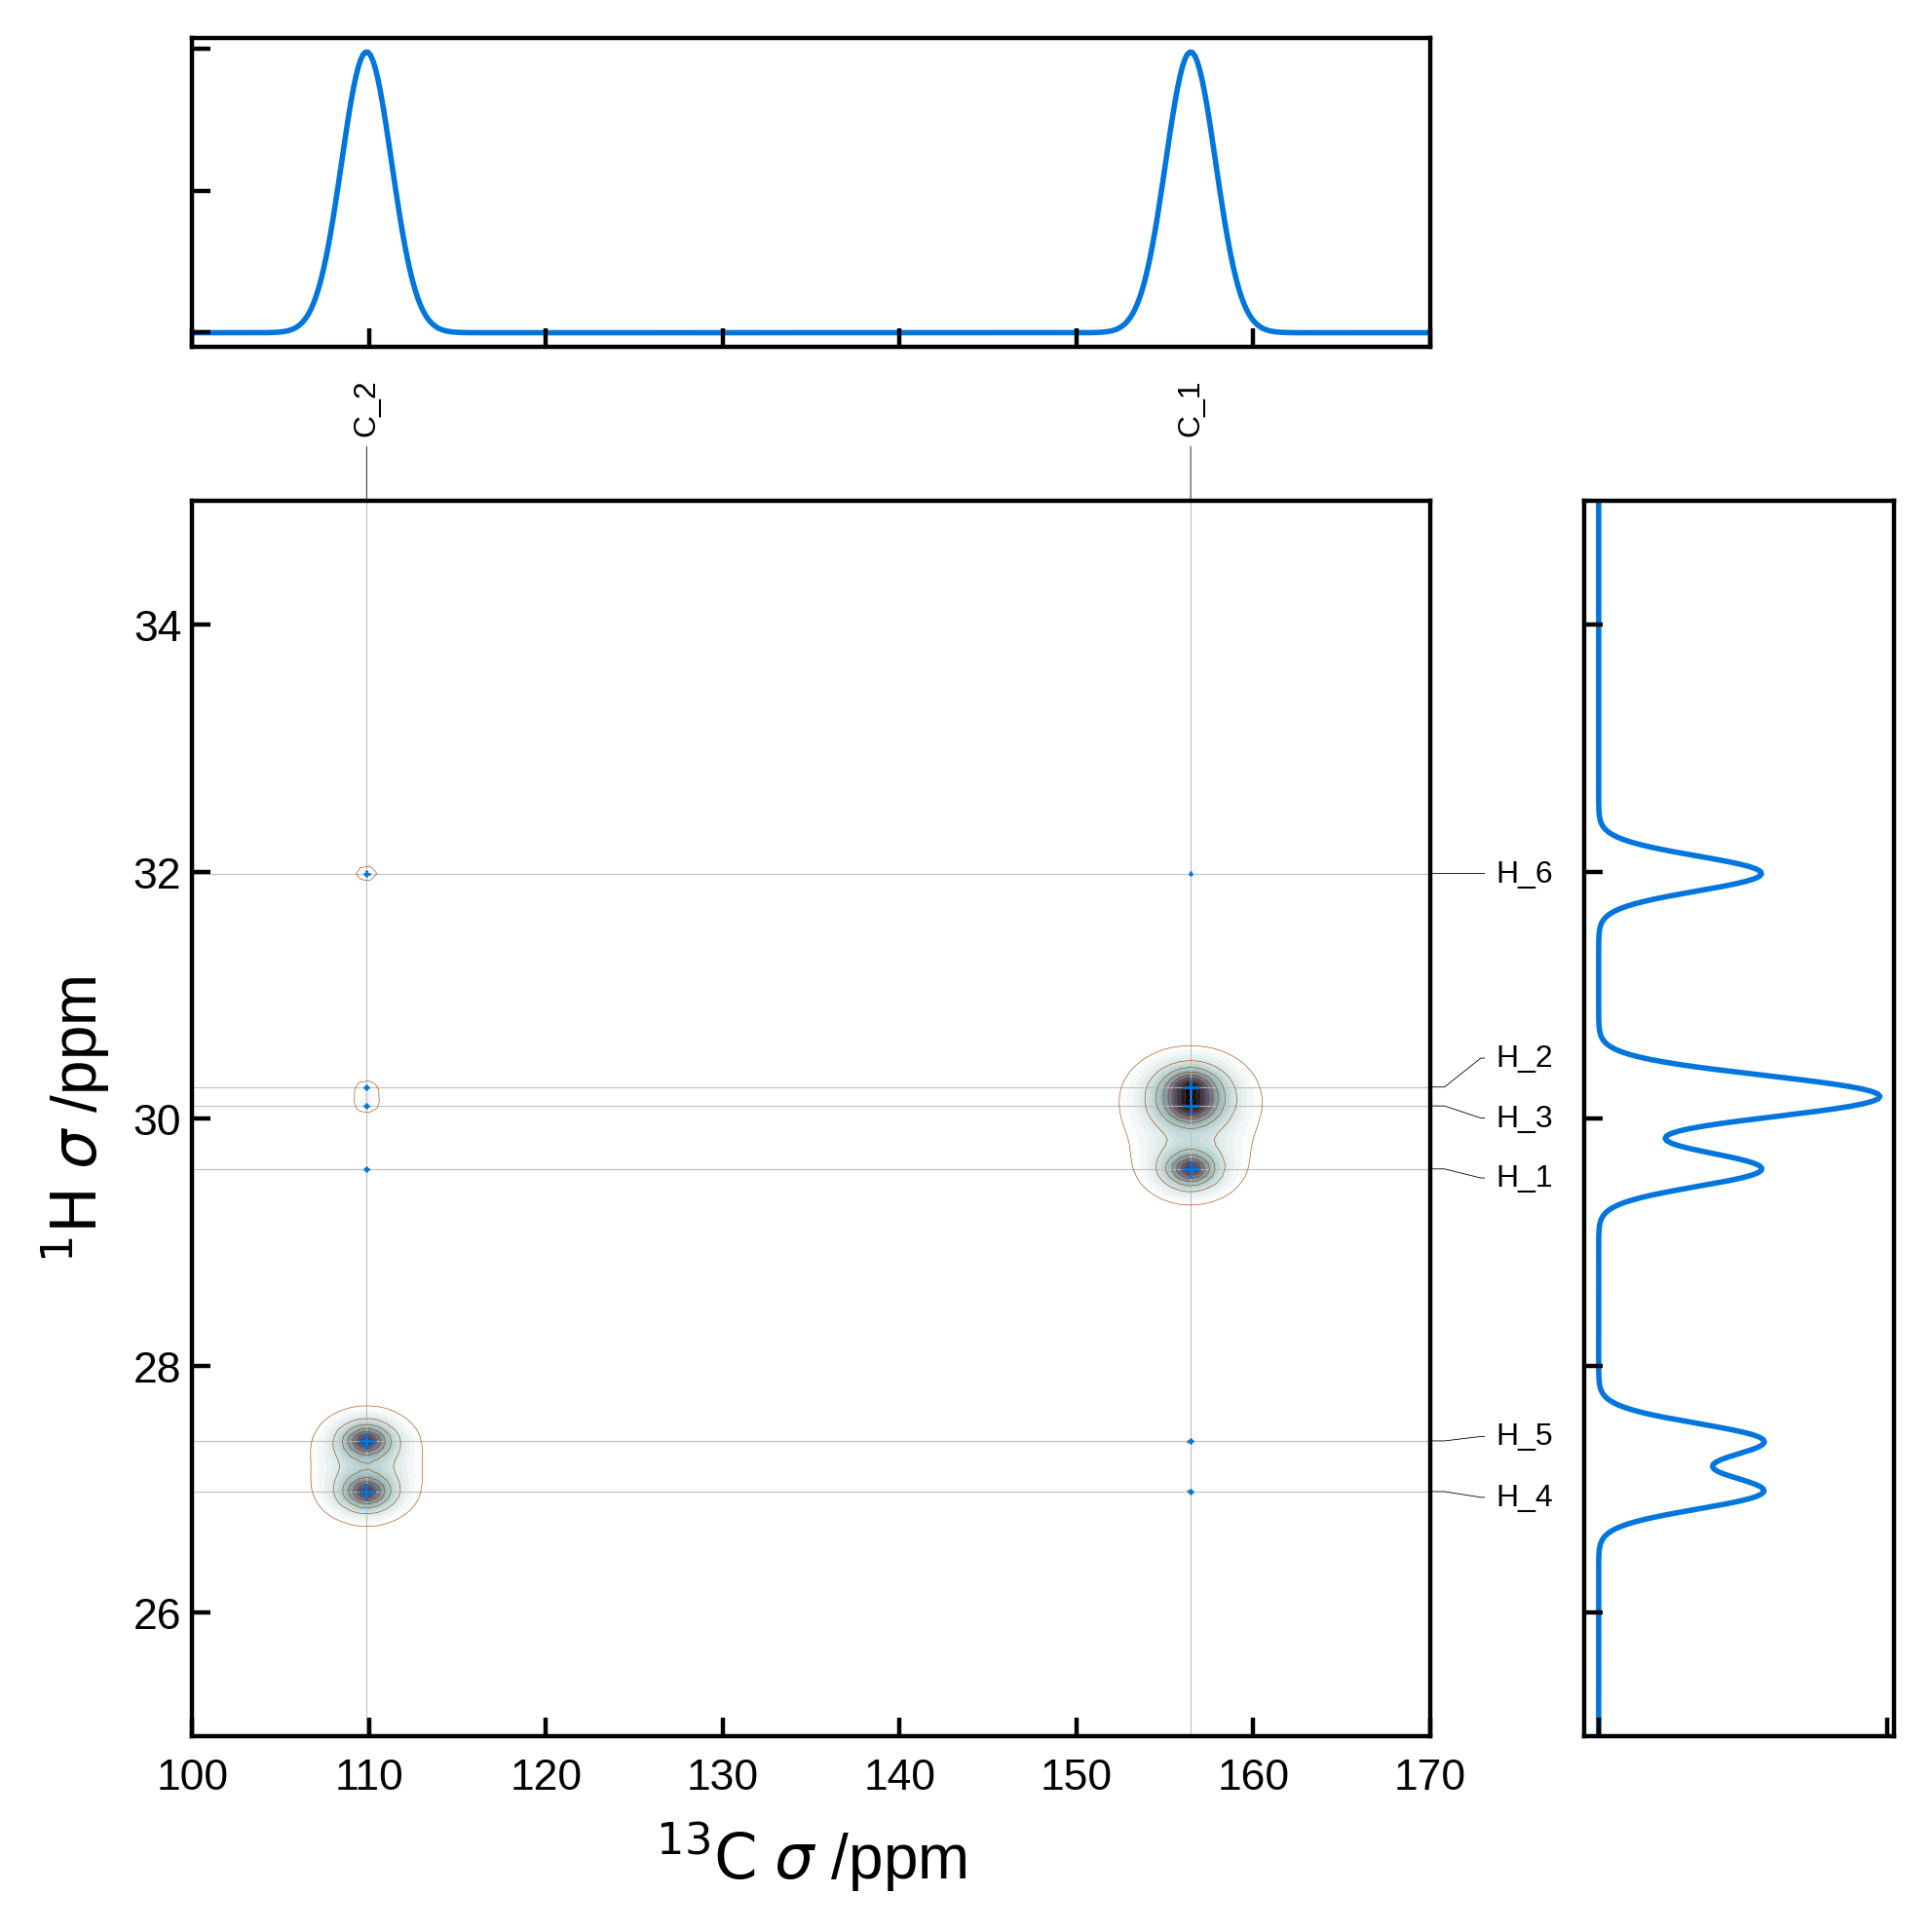

In [9]:
from matplotlib.gridspec import GridSpec

# Common parameters
xlims = (100, 170)
ylims = (25, 35)
nbins = 501
x_broadening = 2.0
y_broadening = 0.2

# Compute the 1D spectra (see Tutorial 05 for more on NMRCalculator)
ncalc = NMRCalculator(ethanol)
ncalc.set_powder(N=1)
spec1H_iso, freqs1H = ncalc.spectrum_1d('1H', effects=NMRFlags.MAS, max_freq=ylims[1], min_freq=ylims[0], bins=nbins, freq_broad=y_broadening)
spec13C_iso, freqs13C = ncalc.spectrum_1d('13C', effects=NMRFlags.MAS, max_freq=xlims[1], min_freq=xlims[0], bins=nbins, freq_broad=x_broadening)

# Build a custom 2D + two 1D axes layout
fig = plt.figure(figsize=(5, 5))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4])

ax1d_x = fig.add_subplot(gs[0, 0])
ax1d_x.plot(freqs13C, spec13C_iso, lw=1)
ax1d_x.set_xlim(xlims)
ax1d_x.set_xticklabels([])
ax1d_x.set_yticklabels([])

ax1d_y = fig.add_subplot(gs[1, 1])
ax1d_y.plot(spec1H_iso, freqs1H, lw=1)
ax1d_y.set_ylim(ylims)
ax1d_y.set_xticklabels([])
ax1d_y.set_yticklabels([])

nmr_data_2d = NMRData2D(ethanol, xelement='C', yelement='H', correlation_strength_metric='dipolar')
ax2d = fig.add_subplot(gs[1, 0])

plot_settings = PlotSettings(
    xlim=xlims,
    ylim=ylims,
    show_heatmap=True,
    show_contour=True,
    x_broadening=x_broadening,
    y_broadening=y_broadening,
    heatmap_levels=40,
    heatmap_grid_size=nbins,
    colormap='bone_r',
    contour_levels=10,
    contour_linewidth=0.1,
)

NMRPlot2D(nmr_data_2d, plot_settings, ax=ax2d).plot()
plt.subplots_adjust(wspace=0.2, hspace=0.2)

### Exporting peaks to a DataFrame

The peak list (positions, labels, and coupling strengths) can be exported to a pandas DataFrame with `to_dataframe()`.  This is useful for tabular inspection or saving to CSV.

In [10]:
df = nmr_data_2d.to_dataframe()
# You can export the df to a csv file if you want
# df.to_csv('nmr_data.csv', index=False)
# Here we just display the dataframe:
df

,x,y,xlabel,ylabel,correlation_strength,xelement,yelement,xisotope,yisotope,correlation_metric,correlation_unit,correlation_label,yaxis_order,is_shift
0,156.467218,29.592619,C_1,H_1,-23.050578,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
1,156.467218,30.256051,C_1,H_2,-23.004866,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
2,156.467218,30.102753,C_1,H_3,-23.188447,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
3,156.467218,26.980027,C_1,H_4,-2.975642,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
4,156.467218,27.390413,C_1,H_5,-2.994557,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
5,156.467218,31.984976,C_1,H_6,-1.669323,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
6,109.857140,29.592619,C_2,H_1,-2.961065,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
7,109.857140,30.256051,C_2,H_2,-2.975401,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
8,109.857140,30.102753,C_2,H_3,-3.026833,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False
9,109.857140,26.980027,C_2,H_4,-22.733525,C,H,13,1,dipolar,kHz,Dipolar Coupling,1Q,False


### Exporting contour data

Below we generate contour data once, preview it, then export it to common formats.

| Format | Extension | Typical use |
|--------|-----------|-------------|
| `'json'` | `.json` | ssNake (recommended) |
| `'simpson'` | `.spe` | SIMPSON-compatible tools |
| `'npz'` | `.npz` | Python/NumPy post-processing |
| `'csv'` | `.csv` | Spreadsheet / Origin |

Grid shape: (200, 200)
Z range: 0.0000 to 1000000.0000
Wrote files to: /home/jks/coding/jks_soprano.worktrees/CCP-NC-master/tutorials/tutorial_data/_tmp_output


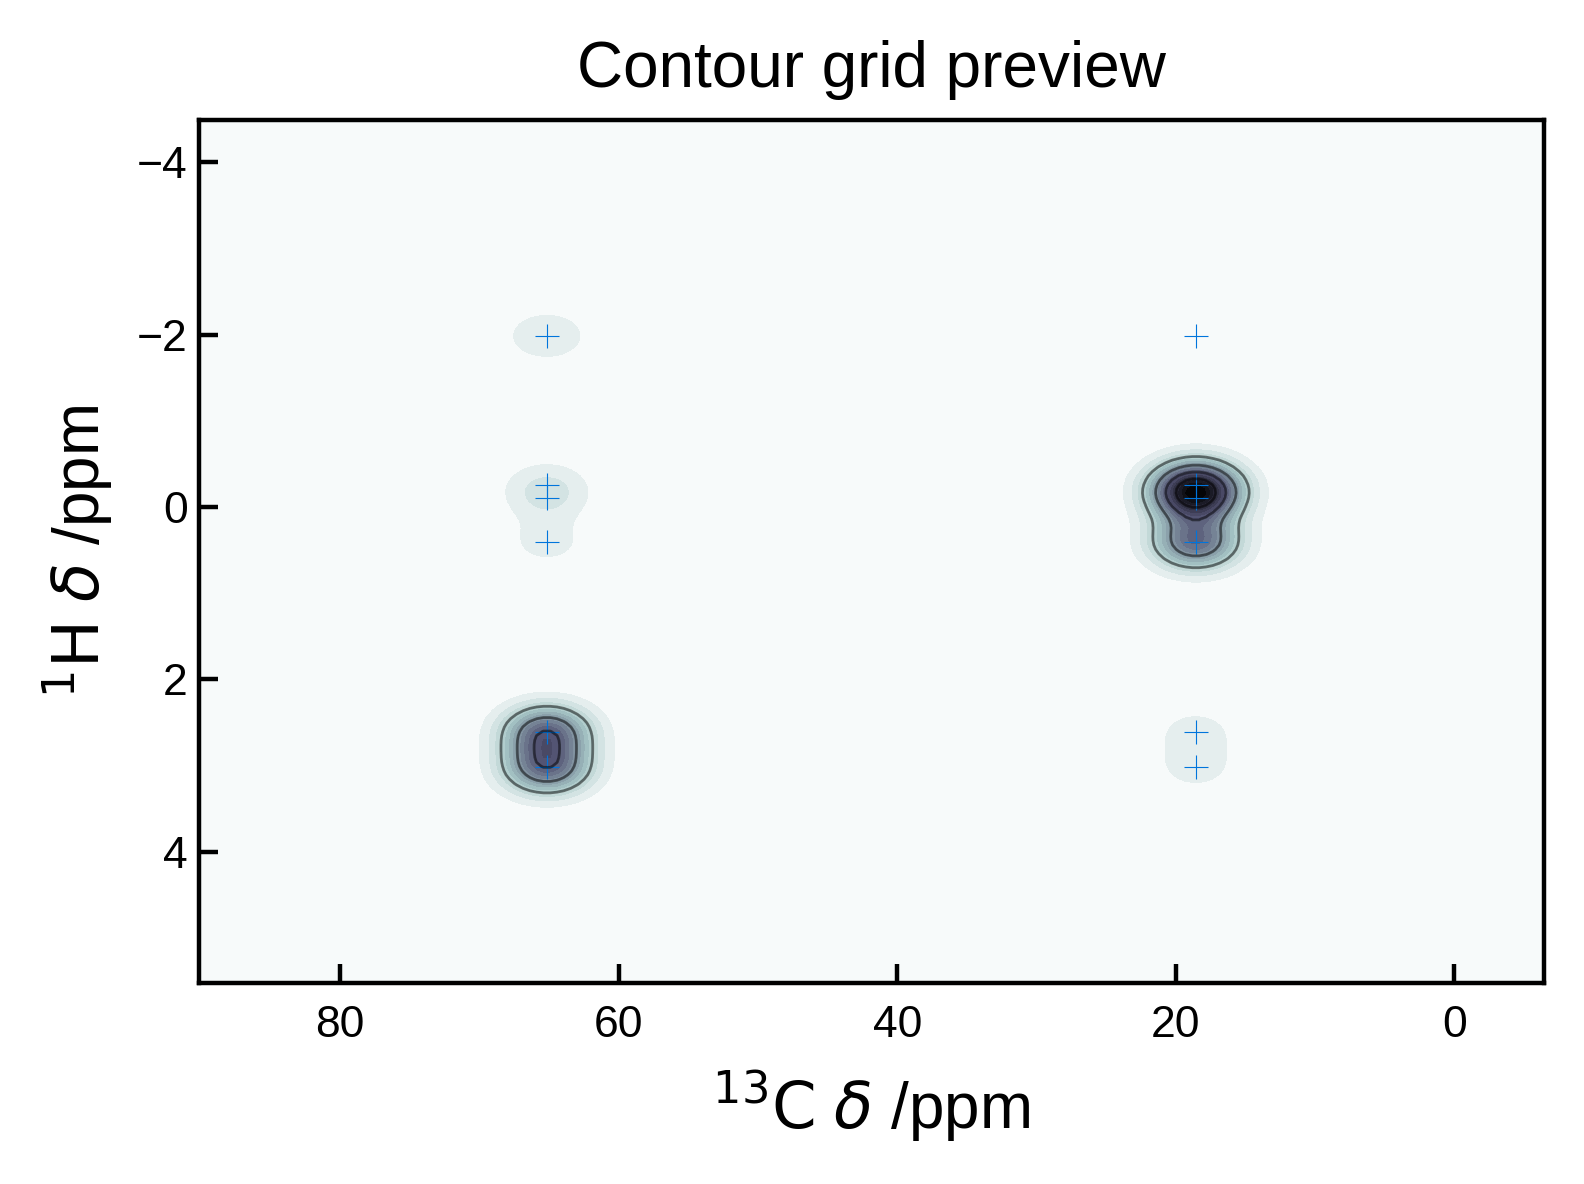

In [ ]:
# Build a heteronuclear C-H map with dipolar correlation strengths, 
# and export the contour data to JSON and NPZ files.
nmr_data_2d = NMRData2D(
    ethanol,
    xelement='C',
    yelement='H',
    references={'C': 175, 'H': 30},
    correlation_strength_metric='dipolar',
)

export_kw = dict(
    x_broadening=5.0,    # FWHM line broadening in x dimension (ppm)
    y_broadening=0.5,    # FWHM line broadening in y dimension (ppm)
    broadening_type='gaussian',
    grid_size=200,       # number of grid points per dimension
    # Scale the computed contour grid so that Z.max() equals grid_max:
    grid_max=1e6, # set this to be in the same ballpark as your experimental intensities.
)

cd = nmr_data_2d.get_contour_data(**export_kw)
print(f"Grid shape: {cd.Z.shape}")
print(f"Z range: {cd.Z.min():.4f} to {cd.Z.max():.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.contourf(cd.X, cd.Y, cd.Z, levels=20, cmap='bone_r')
ax.contour(cd.X, cd.Y, cd.Z, levels=5, colors='k', linewidths=0.5, alpha=0.5)
# Show the original peaks on top of the contour grid:
ax.scatter(
    [p.x for p in nmr_data_2d.peaks],
    [p.y for p in nmr_data_2d.peaks],
    s=20,
    marker='+',
    c='C0',
    label='Peaks',
)
ax.set_xlabel(nmr_data_2d.x_axis_label)
ax.set_ylabel(nmr_data_2d.y_axis_label)
ax.set_title('Contour grid preview')
ax.set_xlim(cd.xlims[1], cd.xlims[0])
ax.set_ylim(cd.ylims[1], cd.ylims[0])
plt.tight_layout()

outdir = Path('tutorial_data') / '_tmp_output'
outdir.mkdir(parents=True, exist_ok=True)

nmr_data_2d.export_contour_data(
    outdir / 'ch_correlation.json',
    fmt='json',
    x_larmor_freq_mhz=100.6,  # ¹³C Larmor frequency at 9.4 T
    y_larmor_freq_mhz=400.1,  # ¹H Larmor frequency at 9.4 T
    **export_kw,
)
nmr_data_2d.export_contour_data(outdir / 'ch_correlation.npz', fmt='npz', **export_kw)

print(f"Wrote files to: {outdir.resolve()}")
# Note: exported files are written to tutorial_data/_tmp_output/ which is git-ignored.

### DQ/SQ ¹H–¹H correlation spectrum of L-alanine

Setting `yaxis_order='2Q'` switches from a conventional (SQ/SQ) NOESY-type 2D plot to a Double-Quantum / Single-Quantum plot:

*  x-axis  →  single-quantum ¹H shift  (δ_i, ppm)
*  y-axis  →  double-quantum frequency (δ_i + δ_j, ppm)

Roofing pairs: for each i–j correlation, two peaks appear at the *same* DQ frequency but at different SQ frequencies (δ_i and δ_j). They are connected by grey horizontal lines (`show_connectors=True`, the default).
The dashed y = 2x diagonal marks the auto-correlation condition (δ_i = δ_j). In L-alanine we expect three chemically distinct ¹H sites:

* NH₃⁺ ≈ 8–9 ppm
* CH ≈ 4–6 ppm
* CH₃ ≈ 1–3 ppm

We need to average the three CH₃ and the three NH₃ protons into single peaks (set `average_group='CH3,NH3'`) to get the expected strong CH₃–CH₃ and NH₃–NH₃ auto-correlation peaks. We also want to use the dipolar RSS as the correlation strength metric.

We start by extracting the peaks and coupling constants from the `.magres` file:


In [37]:

rcut = 6.0  # Å – captures nearest intra- and inter-molecular H–H pairs

alanine = ase_io.read("./tutorial_data/alanine.magres")
nmr_dq = NMRData2D(
    alanine,
    xelement='H',
    yelement='H',
    yaxis_order='2Q',                         # double-quantum / single-quantum mode
    references={'H': 29.5},
    gradients={'H': -0.95},
    rcut=rcut,
    correlation_strength_metric='dipolar_rss', # root-sum-square of all dipolar couplings all equivalent neighbour spins
    rss_cutoff=20, # Å – only include dipolar couplings from spins within this distance for the RSS calculation
    average_group='CH3,NH3'
)

print(f"Number of unique DQ/SQ peaks: {len(nmr_dq.peaks)}")
print("\nStrongest peaks (by dipolar RSS):")
for p in sorted(nmr_dq.peaks, key=lambda p: -abs(p.correlation_strength))[:20]:
    print(f"  SQ={p.x:5.2f} ppm   DQ={p.y:5.2f} ppm   RSS={p.correlation_strength:6.1f} kHz"
          f"   {p.xlabel} ↔ {p.ylabel}")

Number of unique DQ/SQ peaks: 33

Strongest peaks (by dipolar RSS):
  SQ= 8.11 ppm   DQ=16.21 ppm   RSS=  25.1 kHz   H_1,H_4,H_6/H_8,H_11,H_13/H_15,H_18,H_20/H_22,H_25,H_27 ↔ H_1 + H_4,H_1 + H_6,H_4 + H_6/H_11 + H_13,H_11 + H_8,H_13 + H_8/H_15 + H_18,H_15 + H_20,H_18 + H_20/H_22 + H_27,H_22 + H_25,H_25 + H_27
  SQ= 0.99 ppm   DQ= 1.99 ppm   RSS=  22.3 kHz   H_3,H_5,H_7/H_10,H_12,H_14/H_17,H_19,H_21/H_24,H_26,H_28 ↔ H_3 + H_5,H_3 + H_7,H_5 + H_7/H_10 + H_12,H_10 + H_14,H_12 + H_14/H_17 + H_21,H_17 + H_19,H_19 + H_21/H_24 + H_28,H_24 + H_26,H_26 + H_28
  SQ= 8.11 ppm   DQ=11.88 ppm   RSS=   7.8 kHz   H_1,H_4,H_6/H_8,H_11,H_13/H_15,H_18,H_20/H_22,H_25,H_27 ↔ H_1 + H_2,H_2 + H_4,H_2 + H_6/H_8 + H_9,H_11 + H_9,H_13 + H_9/H_15 + H_16,H_16 + H_18,H_16 + H_20/H_22 + H_23,H_23 + H_25,H_23 + H_27
  SQ= 3.78 ppm   DQ=11.88 ppm   RSS=   7.8 kHz   H_2/H_9/H_16/H_23 ↔ H_1 + H_2,H_2 + H_4,H_2 + H_6/H_8 + H_9,H_11 + H_9,H_13 + H_9/H_15 + H_16,H_16 + H_18,H_16 + H_20/H_22 + H_23,H_23 + H_25,H_23 + H_27

In [38]:
# Export to ssNake JSON for interactive exploration:
out_path = Path("alanine_dq.json")
nmr_dq.export_contour_data(
    out_path,
    fmt="json",
    x_larmor_freq_mhz=42.6,   # ¹H Larmor frequency at 1 T
    y_larmor_freq_mhz=85.2,   # 2 × 42.6 MHz for the DQ (double-quantum) axis
    x_broadening=1.5,
    y_broadening=1.5,
    broadening_type='lorentzian',
)
print(f"Exported DQ/SQ data to {out_path.resolve()} for interactive exploration in ssNake!")
print("  In ssNake: File → Open → JSON → alanine_dq.json")

Exported DQ/SQ data to /home/jks/coding/jks_soprano.worktrees/CCP-NC-master/tutorials/alanine_dq.json for interactive exploration in ssNake!
  In ssNake: File → Open → JSON → alanine_dq.json


Text(10.106968872196047, 18.213937744392094, 'Strongest peak\nRSS=25.1 kHz')

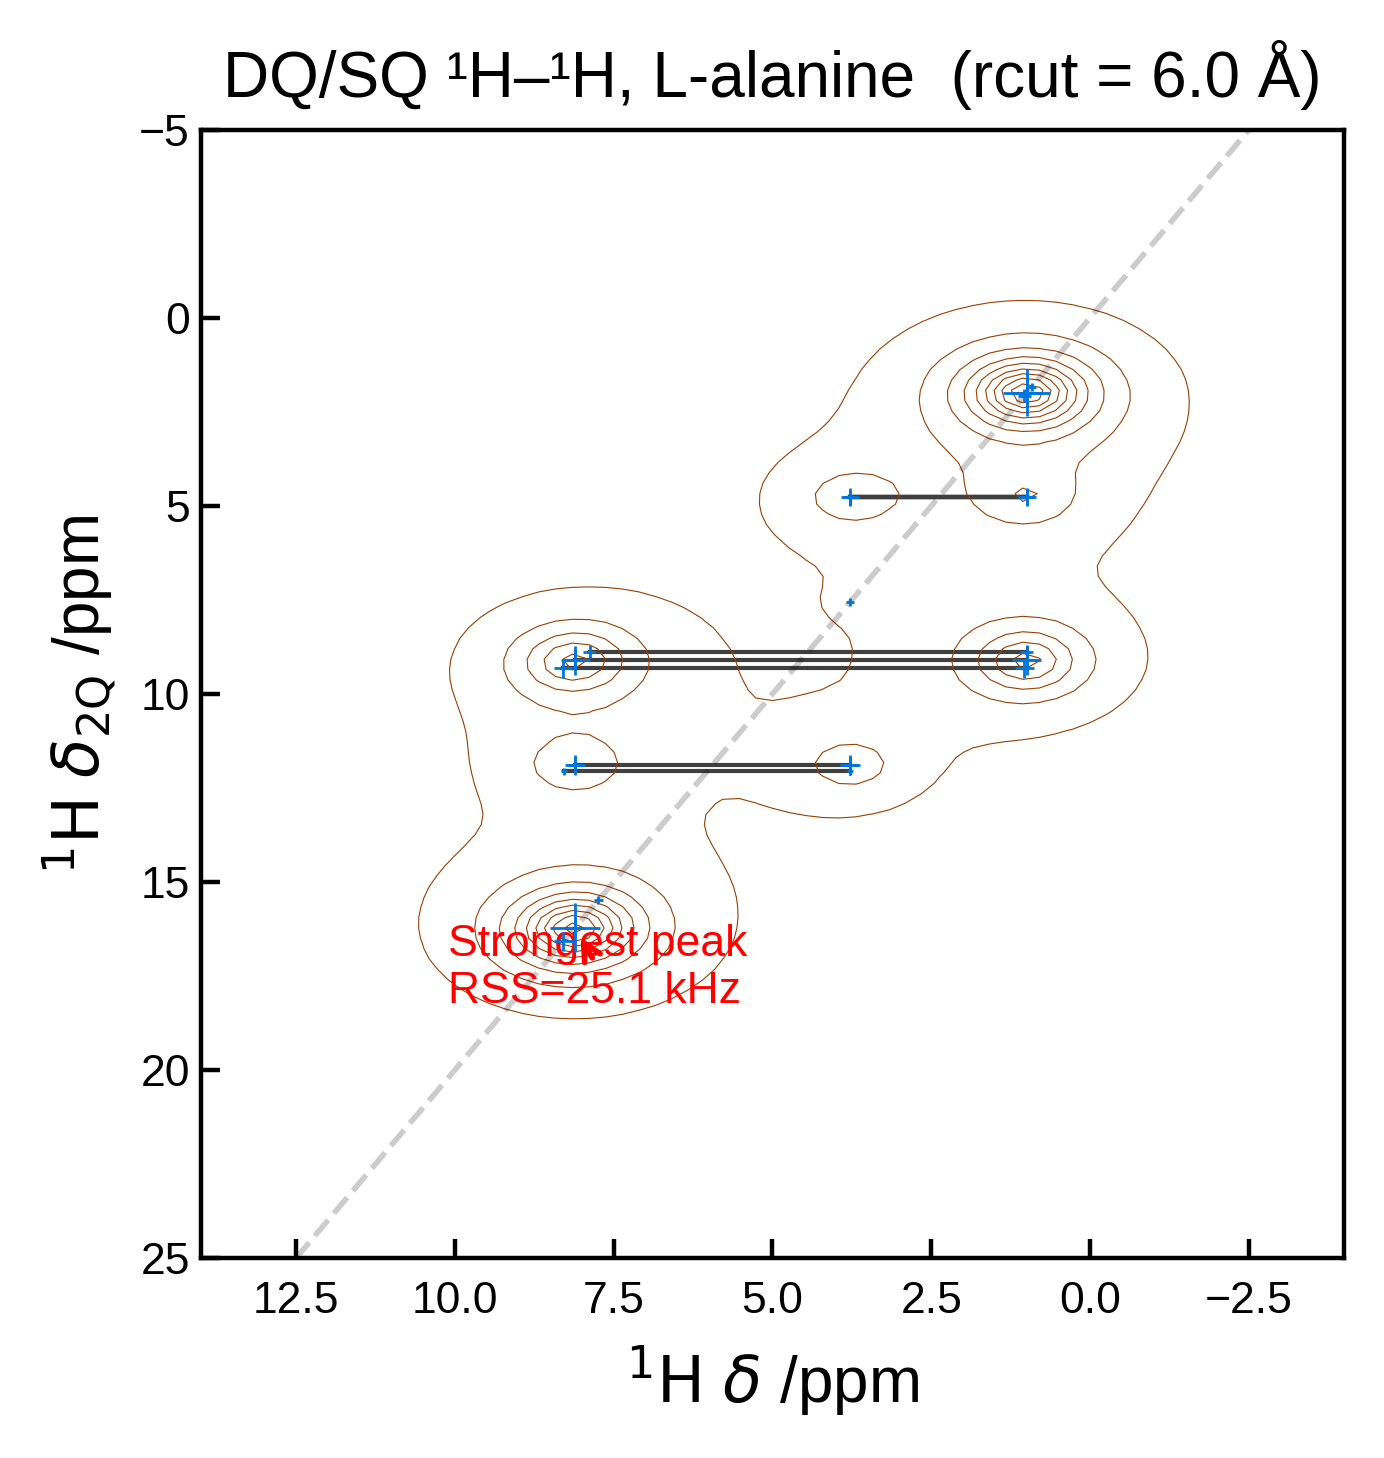

In [40]:
plot_settings = PlotSettings(
    show_contour=True,
    show_markers=True,
    show_connectors=True,       # grey horizontal lines link each roofing pair
    show_diagonal=True,         # dashed y = 2x autocorrelation line
    show_labels=False,
    show_lines = False,
    x_broadening=1.5,
    y_broadening=1.5,
    colormap='bone_r',
    contour_levels=10,
    contour_linewidth=0.2,
    scale_markers=True,
    max_marker_size=80,
    heatmap_grid_size=600,
    broadening_type='lorentzian',
    xlim=(-4, 14),
    ylim=(-5, 25),
)

plot_dq = NMRPlot2D(nmr_dq, plot_settings)
fig, ax = plot_dq.plot()
ax.set_title(f"DQ/SQ ¹H–¹H, L-alanine  (rcut = {rcut} Å)")

# We can add custom annotations to highlight interesting peaks:
# For example, let's annotate the strongest peak:
strongest_peak = max(nmr_dq.peaks, key=lambda p: abs(p.correlation_strength))
ax.annotate(
    f"Strongest peak\nRSS={strongest_peak.correlation_strength:.1f} kHz",
    xy=(strongest_peak.x, strongest_peak.y),
    xytext=(strongest_peak.x + 2, strongest_peak.y + 2),
    arrowprops=dict(arrowstyle="->", color='red'),
    fontsize=8,
    color='red',
)

### Advanced: DQ/SQ with dipolar-RSS weighting and equivalent-site expansion

> **Note:** The sections below cover advanced options for fine-tuning correlation-strength weights. They can safely be skipped on a first reading.

For homonuclear DQ/SQ spectra, `dipolar_rss` weights each peak using couplings to many neighbours.
The `rss_expand_j` option controls how equivalent neighbours are included:

- `periodic_images`: only periodic images of the selected j site
- `cif_labels`: all sites sharing the same CIF label
- `symmetry`: all symmetry-equivalent sites

The example below compares the default and `cif_labels` modes with `reduce=True`.

periodic_images peaks: 276
cif_labels peaks:      276


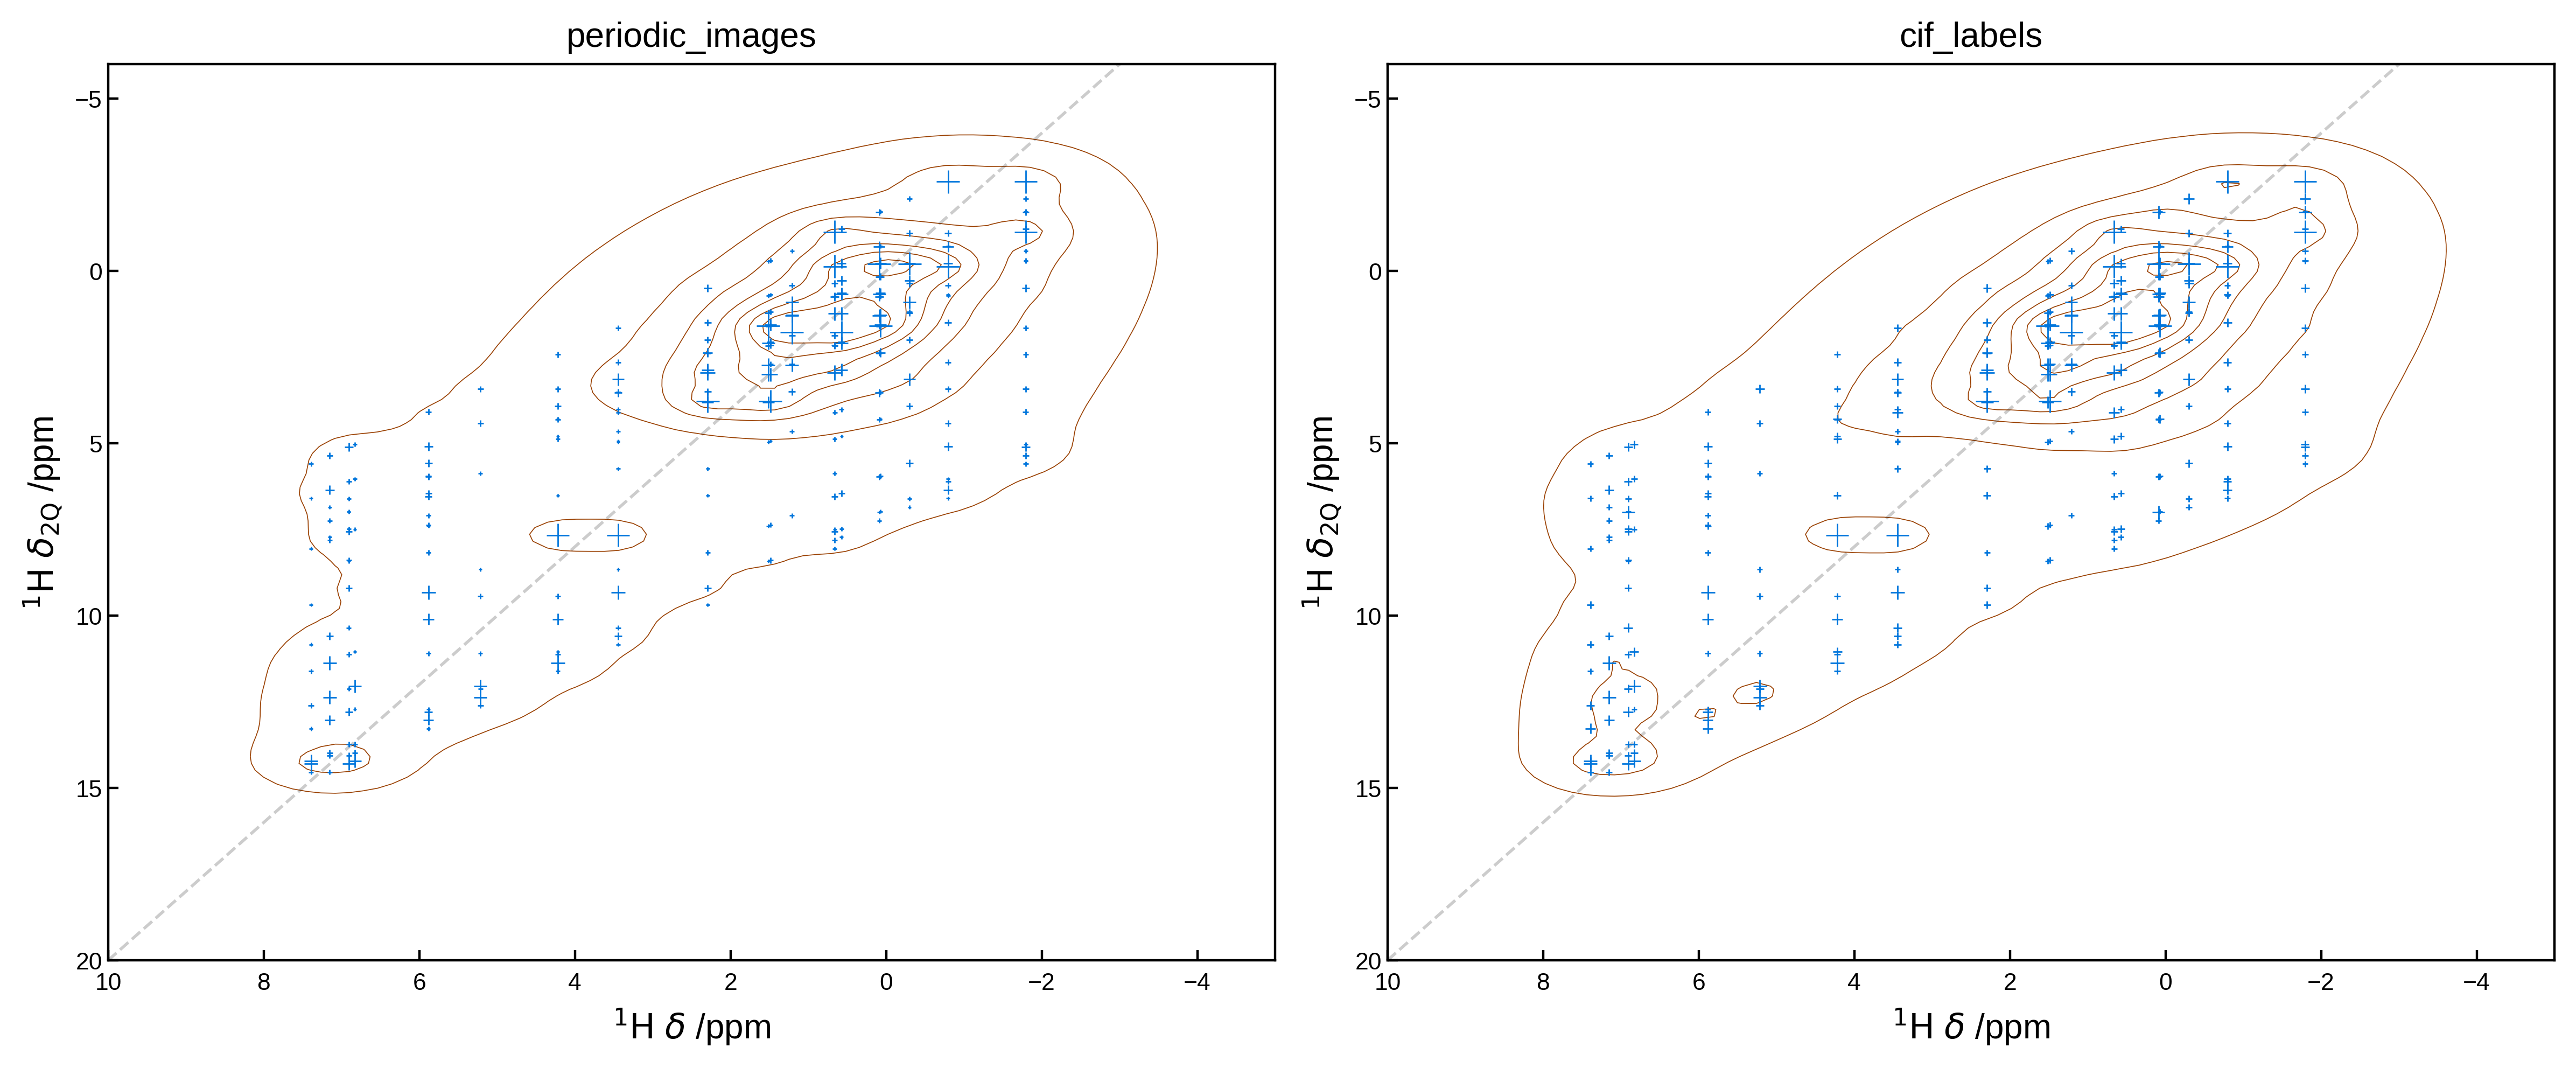

In [15]:
# Compare two rss_expand_j modes on EDIZUM with the same plotting settings.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rss_kw = dict(
    xelement='H',
    yelement='H',
    yaxis_order='2Q',
    rcut=6.0,
    correlation_strength_metric='dipolar_rss',
    rss_cutoff=6.0,
    references={'H': 29.5},
    gradients={'H': -0.95},
    reduce=True,
)
settings_kw = dict(
    show_contour=True,
    show_markers=True,
    show_connectors=False,
    show_diagonal=True,
    show_labels=False,
    show_lines=False,
    x_broadening=1.0,
    y_broadening=1.0,
    broadening_type='lorentzian',
    colormap='bone_r',
    contour_levels=8,
    contour_linewidth=0.3,
    scale_markers=True,
    max_marker_size=60,
    xlim=(10, -5),
    ylim=(20, -6),
)

nmr_dqsq_pbc = NMRData2D(edizum, **rss_kw, rss_expand_j='periodic_images')
NMRPlot2D(nmr_dqsq_pbc, PlotSettings(**settings_kw), ax=axes[0]).plot()
axes[0].set_title('periodic_images')

nmr_dqsq_cif = NMRData2D(edizum, **rss_kw, rss_expand_j='cif_labels')
NMRPlot2D(nmr_dqsq_cif, PlotSettings(**settings_kw), ax=axes[1]).plot()
axes[1].set_title('cif_labels')

print(f"periodic_images peaks: {len(nmr_dqsq_pbc.peaks)}")
print(f"cif_labels peaks:      {len(nmr_dqsq_cif.peaks)}")
plt.tight_layout()

#### Quick numeric comparison of RSS weights

With `reduce=True`, both modes generally produce the same peak positions, but different marker weights.
The cell below compares the strongest peaks in each mode.

In [16]:
# Compare the strongest peaks from the two expansion modes.
top_n = 10

pbc_sorted = sorted(nmr_dqsq_pbc.peaks, key=lambda p: -abs(p.correlation_strength))[:top_n]
cif_sorted = sorted(nmr_dqsq_cif.peaks, key=lambda p: -abs(p.correlation_strength))[:top_n]

print('Top periodic_images peaks:')
for p in pbc_sorted:
    print(f"  {p.xlabel}-{p.ylabel}: {p.correlation_strength:.3f}")

print('\nTop cif_labels peaks:')
for p in cif_sorted:
    print(f"  {p.xlabel}-{p.ylabel}: {p.correlation_strength:.3f}")

Top periodic_images peaks:
  H1-H1 + H2: 29.662
  H2-H1 + H2: 29.662
  H3-H3 + H4: 29.548
  H4-H3 + H4: 29.548
  H5-H5 + H6: 29.414
  H6-H5 + H6: 29.414
  H7-H7 + H8: 29.329
  H8-H7 + H8: 29.329
  H12-H12 + H14: 29.310
  H14-H12 + H14: 29.310

Top cif_labels peaks:
  H5-H5 + H6: 29.802
  H6-H5 + H6: 29.802
  H1-H1 + H2: 29.668
  H2-H1 + H2: 29.668
  H3-H3 + H4: 29.569
  H4-H3 + H4: 29.569
  H7-H7 + H8: 29.345
  H8-H7 + H8: 29.345
  H12-H12 + H13: 29.336
  H13-H12 + H13: 29.336
